# Headline

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Download

In [2]:
!pip install -U vnstock
!pip install optuna

## Import

In [3]:
# === 1. THƯ VIỆN CHUẨN & CẢNH BÁO HỆ THỐNG ===
import math
import os
import pickle
import time
import warnings
from abc import ABC, abstractmethod

warnings.filterwarnings("ignore")
from statsmodels.tools.sm_exceptions import InterpolationWarning
warnings.simplefilter("ignore", InterpolationWarning)

# === 2. XỬ LÝ DỮ LIỆU & TRỰC QUAN HÓA ===
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# === 3. KHOA HỌC DỮ LIỆU & XỬ LÝ TÍN HIỆU (SCIPY) ===
from scipy import stats
from scipy.cluster.hierarchy import fcluster, linkage
from scipy.fft import rfft, rfftfreq
from scipy.spatial.distance import squareform

# === 4. THỐNG KÊ & CHUỖI THỜI GIAN (STATSMODELS) ===
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
from statsmodels.tsa.stattools import acf, adfuller, bds, grangercausalitytests, kpss, pacf

# === 5. MACHINE LEARNING (SCIKIT-LEARN) ===
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit, train_test_split
from sklearn.utils.class_weight import compute_sample_weight

# === 6. TỐI ƯU HÓA, BOOSTING & DỮ LIỆU TÀI CHÍNH ===
import optuna
import xgboost as xgb
import yfinance as yf
from vnstock import *

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from sklearn.pipeline import make_pipeline

# Data Input

In [4]:
class MultiAssetDataPreparer:
    """
    Tải, kiểm toán hình học, chuẩn hóa giá điều chỉnh và lưu trữ dữ liệu
    cho toàn bộ rổ cổ phiếu trong final_portfolio.csv cùng chỉ số VN-Index.
    """
    def __init__(self, portfolio_path: str = 'final_portfolio.csv',
                 start_date: str = '2018-01-01', end_date: str = '2026-06-01',
                 source: str = 'VCI', cache_dir: str = 'data_cache'):
        self.portfolio_path = portfolio_path
        self.start_date = start_date
        self.end_date = end_date
        self.source = source
        self.cache_dir = cache_dir
        os.makedirs(self.cache_dir, exist_ok=True)

        # Đọc danh mục mục tiêu và trích xuất danh sách mã
        self.df_portfolio = pd.read_csv(self.portfolio_path)
        self.tickers = sorted(self.df_portfolio['Ticker'].unique().tolist())
        print(f"[*] Khởi tạo danh mục: {len(self.tickers)} mã cổ phiếu từ {self.portfolio_path}")

    def _fetch_history(self, symbol: str) -> pd.DataFrame:
        """
        Tải dữ liệu OHLCV:
        - Symbol 'VNINDEX': Dùng vnstock (Quote API) từ nguồn VCI.
        - Các mã cổ phiếu khác: Dùng yfinance.
        """
        cache_file = os.path.join(self.cache_dir, f"{symbol}.csv")

        if os.path.exists(cache_file):
            df = pd.read_csv(cache_file)
            df['time'] = pd.to_datetime(df['time'])
            df.set_index('time', inplace=True)
            return df

        try:
            # 1. Tải chỉ số VNINDEX từ vnstock
            if symbol == "VNINDEX":
                q = Quote(symbol='VNINDEX', source=self.source)
                # Lấy dữ liệu lịch sử nến ngày (1D)
                df = q.history(start=self.start_date, end=self.end_date, interval='1D')

                if df is not None and not df.empty:
                    df.reset_index(inplace=True)

                    # Chuẩn hóa tên cột đồng bộ về chữ thường
                    df.rename(columns={col: str(col).lower() for col in df.columns}, inplace=True)

                    # vnstock thường đặt cột thời gian là 'time' hoặc 'date'
                    time_col = 'time' if 'time' in df.columns else 'date'
                    df.rename(columns={time_col: 'time'}, inplace=True)

                    required_cols = ['time', 'open', 'high', 'low', 'close', 'volume']
                    df = df[[col for col in required_cols if col in df.columns]]

                    df['time'] = pd.to_datetime(df['time']).dt.tz_localize(None)
                    df.sort_values(by='time', inplace=True)
                    df.set_index('time', inplace=True)

                    df.to_csv(cache_file)
                    return df

            # 2. Tải các mã cổ phiếu khác từ Yahoo Finance
            else:
                yf_symbol = f"{symbol}.VN"
                ticker_obj = yf.Ticker(yf_symbol)
                df = ticker_obj.history(start=self.start_date, end=self.end_date, interval="1d")

                if df is not None and not df.empty:
                    df.reset_index(inplace=True)

                    df.rename(columns={
                        'Date': 'time', 'Open': 'open', 'High': 'high',
                        'Low': 'low', 'Close': 'close', 'Volume': 'volume'
                    }, inplace=True)

                    df['time'] = pd.to_datetime(df['time']).dt.tz_localize(None)
                    df.sort_values(by='time', inplace=True)
                    df.set_index('time', inplace=True)

                    df.to_csv(cache_file)
                    return df

        except Exception as err:
            print(f"  [!] Lỗi lấy dữ liệu {symbol}: {err}")

        return pd.DataFrame()

    def _clean_and_adjust(self, df: pd.DataFrame, df_mkt: pd.DataFrame) -> pd.DataFrame:
        """Kiểm toán hình học nến và bổ sung biến lợi nhuận thị trường."""
        df = df.copy()

        # 1. Khử trùng lặp và sắp xếp thứ tự thời gian
        df = df[~df.index.duplicated(keep='last')].sort_index()

        # Đo lường khoảng trống thời gian (Trading Calendar Gap)
        time_diff = df.index.to_series().diff().dt.days

        # 2. Kiểm toán biên hình học nến
        max_oc = df[['open', 'close']].max(axis=1)
        min_oc = df[['open', 'close']].min(axis=1)
        df['high'] = np.maximum(df['high'], max_oc)
        df['low'] = np.minimum(df['low'], min_oc)
        df = df[(df['low'] > 0) & (df['volume'] >= 0)]

        # 3. Chuẩn hóa giá điều chỉnh (nếu chưa có sẵn)
        if 'close_adj' not in df.columns:
            df['close_adj'] = df['close']
            ratio = df['close_adj'] / df['close']
            df['open_adj'] = df['open'] * ratio
            df['high_adj'] = df['high'] * ratio
            df['low_adj'] = df['low'] * ratio

        # 4. Tính các chuỗi Log Return cơ sở
        df['log_return'] = np.log(df['close_adj'] / df['close_adj'].shift(1))
        df['overnight_return'] = np.log(df['open_adj'] / df['close_adj'].shift(1))
        df['intraday_return'] = np.log(df['close_adj'] / df['open_adj'])
        df['hl_log_range'] = np.log(df['high_adj'] / df['low_adj'])

        # Hủy bỏ các return ảo sinh ra do đình chỉ giao dịch (> 7 ngày)
        suspension_mask = time_diff > 7
        df.loc[suspension_mask, ['log_return', 'overnight_return']] = np.nan

        # 5. Ghép lợi nhuận VN-Index làm biến ngoại sinh
        if not df_mkt.empty:
            df = df.join(df_mkt, how='left')
            mkt_price_cols = ['mkt_close', 'mkt_volume', 'mkt_high', 'mkt_low']
            df[mkt_price_cols] = df[mkt_price_cols].ffill()

            if 'mkt_return' in df.columns:
                df['mkt_return'] = df['mkt_return'].fillna(0.0)

        return df.dropna(subset=['close_adj', 'open_adj'])

    def prepare_dataset(self) -> dict[str, pd.DataFrame]:
        """Thực thi tải và làm sạch toàn bộ dữ liệu danh mục."""
        print("[*] Đang tải dữ liệu Benchmark VN-INDEX...")
        df_mkt = self._fetch_history('VNINDEX')

        if not df_mkt.empty:
            # 1. CHUẨN HÓA THỜI GIAN: Loại bỏ phần giờ/phút/giây (VD: 07:00:00 -> 00:00:00)
            df_mkt.index = pd.to_datetime(df_mkt.index).normalize()

            # 2. Khử trùng lặp (nếu việc loại bỏ múi giờ gây ra trùng ngày)
            df_mkt = df_mkt[~df_mkt.index.duplicated(keep='last')]
            df_mkt.sort_index(inplace=True)

            df_mkt = df_mkt[['close', 'volume', 'high', 'low']].rename(columns={
                'close': 'mkt_close',
                'volume': 'mkt_volume',
                'high': 'mkt_high',
                'low': 'mkt_low'
            })
            df_mkt['mkt_return'] = np.log(df_mkt['mkt_close'] / df_mkt['mkt_close'].shift(1))
        else:
            print("  [!] Cảnh báo: Không thể tải dữ liệu VNINDEX benchmark.")

        clean_dict = {}
        for idx, ticker in enumerate(self.tickers, 1):
            print(f"[{idx:02d}/{len(self.tickers):02d}] Chuẩn bị dữ liệu: {ticker}...")
            df_raw = self._fetch_history(ticker)
            if not df_raw.empty and len(df_raw) > 50:
                clean_df = self._clean_and_adjust(df_raw, df_mkt)
                clean_dict[ticker] = clean_df
            else:
                print(f"  [!] Bỏ qua {ticker} (dữ liệu rỗng hoặc không đủ số phiên tối thiểu).")
            time.sleep(1)

        print(f"\n[✓] HOÀN TẤT BƯỚC DATA PREP: Sẵn sàng {len(clean_dict)}/{len(self.tickers)} mã cổ phiếu cho khâu Modeling.")
        return clean_dict

## Port. Index Preparation:

In [5]:
# =====================================================================
# THỰC THI CHUẨN BỊ DỮ LIỆU
# =====================================================================
portfolio_path = "/content/drive/MyDrive/Colab Notebooks/AI agent in Portfolio Management/Compiled Dataset/final_portfolio.csv"

data_preparer = MultiAssetDataPreparer(
    portfolio_path=portfolio_path,
    start_date='2018-07-01',
    end_date='2026-06-01',
    source='KBS'
)

clean_price_dict = data_preparer.prepare_dataset()

[*] Khởi tạo danh mục: 49 mã cổ phiếu từ /content/drive/MyDrive/Colab Notebooks/AI agent in Portfolio Management/Compiled Dataset/final_portfolio.csv
[*] Đang tải dữ liệu Benchmark VN-INDEX...
[01/49] Chuẩn bị dữ liệu: ABT...
[02/49] Chuẩn bị dữ liệu: ADP...
[03/49] Chuẩn bị dữ liệu: BMP...
[04/49] Chuẩn bị dữ liệu: BRC...
[05/49] Chuẩn bị dữ liệu: CHP...
[06/49] Chuẩn bị dữ liệu: CSM...
[07/49] Chuẩn bị dữ liệu: CSV...
[08/49] Chuẩn bị dữ liệu: CTI...
[09/49] Chuẩn bị dữ liệu: DGC...
[10/49] Chuẩn bị dữ liệu: DHC...
[11/49] Chuẩn bị dữ liệu: DPR...
[12/49] Chuẩn bị dữ liệu: DRL...
[13/49] Chuẩn bị dữ liệu: DSN...
[14/49] Chuẩn bị dữ liệu: DVP...
[15/49] Chuẩn bị dữ liệu: FMC...
[16/49] Chuẩn bị dữ liệu: FPT...
[17/49] Chuẩn bị dữ liệu: GHC...
[18/49] Chuẩn bị dữ liệu: HDG...
[19/49] Chuẩn bị dữ liệu: HT1...
[20/49] Chuẩn bị dữ liệu: HTG...
[21/49] Chuẩn bị dữ liệu: HTI...
[22/49] Chuẩn bị dữ liệu: LGC...
[23/49] Chuẩn bị dữ liệu: LIX...
[24/49] Chuẩn bị dữ liệu: MCH...
[25/49] Chuẩn b

## Data Visualization

In [6]:
print(len(clean_price_dict.keys()))
print(clean_price_dict.keys())

49
dict_keys(['ABT', 'ADP', 'BMP', 'BRC', 'CHP', 'CSM', 'CSV', 'CTI', 'DGC', 'DHC', 'DPR', 'DRL', 'DSN', 'DVP', 'FMC', 'FPT', 'GHC', 'HDG', 'HT1', 'HTG', 'HTI', 'LGC', 'LIX', 'MCH', 'MWG', 'NCT', 'NNC', 'NT2', 'PTB', 'REE', 'SAB', 'SAV', 'SBA', 'SCS', 'SHP', 'SJD', 'SMB', 'TCL', 'TCM', 'TDM', 'TLG', 'TRA', 'TRC', 'TTA', 'VIP', 'VMD', 'VNM', 'VPD', 'VTO'])


In [7]:
# =====================================================================
# 5. HIỂN THỊ KIỂM TOÁN VẬT LÝ VÀ CHẨN ĐOÁN NANs ĐẦU VÀO
# =====================================================================
def raw_data_profile(df_raw, SYMBOL):
    print("\n" + "=" * 80)
    print(f"TỔNG QUAN DATASET KẾT HỢP (DAILY + MICROSTRUCTURE):")
    print(f"- Số dòng tổng cộng      : {len(df_raw):,}")
    print(f"- Mã cổ phiếu            : {SYMBOL}")
    print(f"- Khung thời gian        : Từ {df_raw.index.min().date()} đến {df_raw.index.max().date()}")
    print(f"- Tổng giá trị khuyết NaN: {df_raw.isna().sum().sum()}")
    print("=" * 80)

    # Hiển thị danh sách các cột hiện có để xác nhận Vi cấu trúc đã được gộp thành công
    print(f"\n[Các cột dữ liệu hiện có]:\n{df_raw.columns.tolist()}\n")

    # Hiển thị cấu trúc mẫu
    display(df_raw.head())
    display(df_raw.tail())

    print("\n" * 2)
    print(f"No. NaN values: {df_raw.isna().sum().sum()}")
    if df_raw.isna().sum().sum() > 0:
        display(df_raw.isna().sum()[df_raw.isna().sum() > 0])
    else:
        print("Dữ liệu hoàn hảo, không có giá trị khuyết thiếu!")


for key, value in clean_price_dict.items():
    raw_data_profile(df_raw=value, SYMBOL=key)


TỔNG QUAN DATASET KẾT HỢP (DAILY + MICROSTRUCTURE):
- Số dòng tổng cộng      : 2,056
- Mã cổ phiếu            : ABT
- Khung thời gian        : Từ 2018-07-02 đến 2026-05-29
- Tổng giá trị khuyết NaN: 2

[Các cột dữ liệu hiện có]:
['open', 'high', 'low', 'close', 'volume', 'Dividends', 'Stock Splits', 'close_adj', 'open_adj', 'high_adj', 'low_adj', 'log_return', 'overnight_return', 'intraday_return', 'hl_log_range', 'mkt_close', 'mkt_volume', 'mkt_high', 'mkt_low', 'mkt_return']



,open,high,low,close,volume,Dividends,Stock Splits,close_adj,open_adj,high_adj,low_adj,log_return,overnight_return,intraday_return,hl_log_range,mkt_close,mkt_volume,mkt_high,mkt_low,mkt_return
time,,,,,,,,,,,,,,,,,,,,
2018-07-02,21368.742385,23226.893897,21368.742385,23077.042969,80,0.0,0.0,23077.042969,21368.742385,23226.893897,21368.742385,NaN,NaN,0.076909,0.083382,947.15,142222740.0,960.78,932.66,0.000000
2018-07-03,23077.042969,23077.042969,23077.042969,23077.042969,0,0.0,0.0,23077.042969,23077.042969,23077.042969,23077.042969,0.000000,0.000000,0.000000,0.000000,906.01,161389340.0,946.16,906.01,-0.044407
2018-07-04,21488.623128,23077.042969,21488.623128,23077.042969,150,0.0,0.0,23077.042969,21488.623128,23077.042969,21488.623128,0.000000,-0.071315,0.071315,0.071315,914.99,115604640.0,914.99,890.83,0.009863
2018-07-05,22477.635084,22477.635084,21488.619141,21488.619141,1550,0.0,0.0,21488.619141,22477.635084,22477.635084,21488.619141,-0.071315,-0.026317,-0.044997,0.044997,899.40,127434590.0,921.85,892.67,-0.017185
2018-07-06,21009.098987,22777.339844,20979.128803,22777.339844,1030,0.0,0.0,22777.339844,21009.098987,22777.339844,20979.128803,0.058243,-0.022568,0.080811,0.082238,917.51,141624520.0,921.75,884.99,0.019936


,open,high,low,close,volume,Dividends,Stock Splits,close_adj,open_adj,high_adj,low_adj,log_return,overnight_return,intraday_return,hl_log_range,mkt_close,mkt_volume,mkt_high,mkt_low,mkt_return
time,,,,,,,,,,,,,,,,,,,,
2026-05-25,55200.0,55200.0,55200.0,55200.0,1700,0.0,0.0,55200.0,55200.0,55200.0,55200.0,0.001813,0.001813,0.000000,0.000000,1886.03,495245425.0,1891.26,1876.37,0.004730
2026-05-26,55900.0,56500.0,55900.0,56100.0,7000,0.0,0.0,56100.0,55900.0,56500.0,55900.0,0.016173,0.012601,0.003571,0.010676,1884.18,598836621.0,1889.15,1876.32,-0.000981
2026-05-27,56100.0,56400.0,56100.0,56400.0,2300,0.0,0.0,56400.0,56100.0,56400.0,56100.0,0.005333,0.000000,0.005333,0.005333,1874.43,667675136.0,1889.87,1863.18,-0.005188
2026-05-28,56700.0,57000.0,56400.0,56400.0,4000,0.0,0.0,56400.0,56700.0,57000.0,56400.0,0.000000,0.005305,-0.005305,0.010582,1863.67,602798527.0,1882.66,1857.25,-0.005757
2026-05-29,56000.0,56000.0,56000.0,56000.0,200,0.0,0.0,56000.0,56000.0,56000.0,56000.0,-0.007117,-0.007117,0.000000,0.000000,1863.49,556018675.0,1873.17,1855.96,-0.000097





No. NaN values: 2


,0
log_return,1
overnight_return,1


...


TỔNG QUAN DATASET KẾT HỢP (DAILY + MICROSTRUCTURE):
- Số dòng tổng cộng      : 2,052
- Mã cổ phiếu            : VTO
- Khung thời gian        : Từ 2018-07-02 đến 2026-05-29
- Tổng giá trị khuyết NaN: 2

[Các cột dữ liệu hiện có]:
['open', 'high', 'low', 'close', 'volume', 'Dividends', 'Stock Splits', 'close_adj', 'open_adj', 'high_adj', 'low_adj', 'log_return', 'overnight_return', 'intraday_return', 'hl_log_range', 'mkt_close', 'mkt_volume', 'mkt_high', 'mkt_low', 'mkt_return']



,open,high,low,close,volume,Dividends,Stock Splits,close_adj,open_adj,high_adj,low_adj,log_return,overnight_return,intraday_return,hl_log_range,mkt_close,mkt_volume,mkt_high,mkt_low,mkt_return
time,,,,,,,,,,,,,,,,,,,,
2018-07-02,3549.040278,3633.070480,3549.040278,3593.526855,13680,0.0,0.0,3593.526855,3549.040278,3633.070480,3549.040278,NaN,NaN,0.012457,0.023401,947.15,142222740.0,960.78,932.66,0.000000
2018-07-03,3558.926270,3558.926270,3558.926270,3558.926270,500,0.0,0.0,3558.926270,3558.926270,3558.926270,3558.926270,-0.009675,-9.675242e-03,0.000000,0.000000,906.01,161389340.0,946.16,906.01,-0.044407
2018-07-04,3652.842290,3652.842290,3558.926183,3608.355713,610,0.0,0.0,3608.355713,3652.842290,3652.842290,3558.926183,0.013793,2.604668e-02,-0.012253,0.026047,914.99,115604640.0,914.99,890.83,0.009863
2018-07-05,3608.356773,3628.128591,3509.497683,3603.413818,16610,0.0,0.0,3603.413818,3608.356773,3628.128591,3509.497683,-0.001371,2.937493e-07,-0.001371,0.033244,899.40,127434590.0,921.85,892.67,-0.017185
2018-07-06,3603.413818,3603.413818,3509.497683,3603.413818,1320,0.0,0.0,3603.413818,3603.413818,3603.413818,3509.497683,0.000000,0.000000e+00,0.000000,0.026409,917.51,141624520.0,921.75,884.99,0.019936


,open,high,low,close,volume,Dividends,Stock Splits,close_adj,open_adj,high_adj,low_adj,log_return,overnight_return,intraday_return,hl_log_range,mkt_close,mkt_volume,mkt_high,mkt_low,mkt_return
time,,,,,,,,,,,,,,,,,,,,
2026-05-25,10781.557617,10872.541226,10781.557617,10781.557617,111900,0.0,0.0,10781.557617,10781.557617,10872.541226,10781.557617,0.000000,0.000000e+00,0.000000,0.008403,1886.03,495245425.0,1891.26,1876.37,0.004730
2026-05-26,10827.048625,11054.507629,10827.048625,10918.032227,178800,0.0,0.0,10918.032227,10827.048625,11054.507629,10827.048625,0.012579,4.210459e-03,0.008368,0.020791,1884.18,598836621.0,1889.15,1876.32,-0.000981
2026-05-27,11100.000210,11100.000210,10918.032993,11009.016602,214300,0.0,0.0,11009.016602,11100.000210,11100.000210,10918.032993,0.008299,1.652937e-02,-0.008230,0.016529,1874.43,667675136.0,1889.87,1863.18,-0.005188
2026-05-28,11009.016602,11054.508406,10963.524797,11009.016602,107800,0.0,0.0,11009.016602,11009.016602,11054.508406,10963.524797,0.000000,0.000000e+00,0.000000,0.008265,1863.67,602798527.0,1882.66,1857.25,-0.005757
2026-05-29,11009.016393,11190.983607,11009.016393,11100.000000,248800,0.0,0.0,11100.000000,11009.016393,11190.983607,11009.016393,0.008230,-1.890449e-08,0.008230,0.016394,1863.49,556018675.0,1873.17,1855.96,-0.000097





No. NaN values: 2


,0
log_return,1
overnight_return,1


### làm sạch là loại bỏ NaN trong Return:

In [8]:
for key, value in clean_price_dict.items():
    clean_price_dict[key] = value.dropna()
    raw_data_profile(df_raw=clean_price_dict[key], SYMBOL=key)

# Lưu dict vào file nhị phân (.pkl)
with open("clean_price_dict.pkl", "wb") as f:
    pickle.dump(clean_price_dict, f)


TỔNG QUAN DATASET KẾT HỢP (DAILY + MICROSTRUCTURE):
- Số dòng tổng cộng      : 2,055
- Mã cổ phiếu            : ABT
- Khung thời gian        : Từ 2018-07-03 đến 2026-05-29
- Tổng giá trị khuyết NaN: 0

[Các cột dữ liệu hiện có]:
['open', 'high', 'low', 'close', 'volume', 'Dividends', 'Stock Splits', 'close_adj', 'open_adj', 'high_adj', 'low_adj', 'log_return', 'overnight_return', 'intraday_return', 'hl_log_range', 'mkt_close', 'mkt_volume', 'mkt_high', 'mkt_low', 'mkt_return']



,open,high,low,close,volume,Dividends,Stock Splits,close_adj,open_adj,high_adj,low_adj,log_return,overnight_return,intraday_return,hl_log_range,mkt_close,mkt_volume,mkt_high,mkt_low,mkt_return
time,,,,,,,,,,,,,,,,,,,,
2018-07-03,23077.042969,23077.042969,23077.042969,23077.042969,0,0.0,0.0,23077.042969,23077.042969,23077.042969,23077.042969,0.000000,0.000000,0.000000,0.000000,906.01,161389340.0,946.16,906.01,-0.044407
2018-07-04,21488.623128,23077.042969,21488.623128,23077.042969,150,0.0,0.0,23077.042969,21488.623128,23077.042969,21488.623128,0.000000,-0.071315,0.071315,0.071315,914.99,115604640.0,914.99,890.83,0.009863
2018-07-05,22477.635084,22477.635084,21488.619141,21488.619141,1550,0.0,0.0,21488.619141,22477.635084,22477.635084,21488.619141,-0.071315,-0.026317,-0.044997,0.044997,899.40,127434590.0,921.85,892.67,-0.017185
2018-07-06,21009.098987,22777.339844,20979.128803,22777.339844,1030,0.0,0.0,22777.339844,21009.098987,22777.339844,20979.128803,0.058243,-0.022568,0.080811,0.082238,917.51,141624520.0,921.75,884.99,0.019936
2018-07-09,23556.562500,23556.562500,23556.562500,23556.562500,10,0.0,0.0,23556.562500,23556.562500,23556.562500,23556.562500,0.033638,0.033638,0.000000,0.000000,915.12,106167080.0,929.50,915.12,-0.002608


,open,high,low,close,volume,Dividends,Stock Splits,close_adj,open_adj,high_adj,low_adj,log_return,overnight_return,intraday_return,hl_log_range,mkt_close,mkt_volume,mkt_high,mkt_low,mkt_return
time,,,,,,,,,,,,,,,,,,,,
2026-05-25,55200.0,55200.0,55200.0,55200.0,1700,0.0,0.0,55200.0,55200.0,55200.0,55200.0,0.001813,0.001813,0.000000,0.000000,1886.03,495245425.0,1891.26,1876.37,0.004730
2026-05-26,55900.0,56500.0,55900.0,56100.0,7000,0.0,0.0,56100.0,55900.0,56500.0,55900.0,0.016173,0.012601,0.003571,0.010676,1884.18,598836621.0,1889.15,1876.32,-0.000981
2026-05-27,56100.0,56400.0,56100.0,56400.0,2300,0.0,0.0,56400.0,56100.0,56400.0,56100.0,0.005333,0.000000,0.005333,0.005333,1874.43,667675136.0,1889.87,1863.18,-0.005188
2026-05-28,56700.0,57000.0,56400.0,56400.0,4000,0.0,0.0,56400.0,56700.0,57000.0,56400.0,0.000000,0.005305,-0.005305,0.010582,1863.67,602798527.0,1882.66,1857.25,-0.005757
2026-05-29,56000.0,56000.0,56000.0,56000.0,200,0.0,0.0,56000.0,56000.0,56000.0,56000.0,-0.007117,-0.007117,0.000000,0.000000,1863.49,556018675.0,1873.17,1855.96,-0.000097





No. NaN values: 0
Dữ liệu hoàn hảo, không có giá trị khuyết thiếu!

TỔNG QUAN DATASET KẾT HỢP (DAILY + MICROSTRUCTURE):
- Số dòng tổng cộng      : 732
- Mã cổ phiếu            : ADP
- Khung thời gian        : Từ 2023-07-28 đến 2026-05-29
- Tổng giá trị khuyết NaN: 0

[Các cột dữ liệu hiện có]:
['open', 'high', 'low', 'close', 'volume', 'Dividends', 'Stock Splits', 'close_adj', 'open_adj', 'high_adj', 'low_adj', 'log_return', 'overnight_return', 'intraday_return', 'hl_log_range', 'mkt_close', 'mkt_volume', 'mkt_high', 'mkt_low', 'mkt_return']



,open,high,low,close,volume,Dividends,Stock Splits,close_adj,open_adj,high_adj,low_adj,log_return,overnight_return,intraday_return,hl_log_range,mkt_close,mkt_volume,mkt_high,mkt_low,mkt_return
time,,,,,,,,,,,,,,,,,,,,
2023-07-28,13525.739075,13525.739075,13052.338207,13153.781250,5500,0.0,0.0,13153.781250,13525.739075,13525.739075,13052.338207,-0.062287,-0.034401,-0.027885,0.035627,1207.67,1.045384e+09,1207.67,1195.86,0.008599
2023-07-31,13119.965820,13525.737959,12950.894096,13119.965820,5000,0.0,0.0,13119.965820,13119.965820,13525.737959,12950.894096,-0.002574,-0.002574,0.000000,0.043430,1222.90,1.122988e+09,1224.81,1212.81,0.012532
2023-08-01,13018.523859,13153.781250,12443.679949,13153.781250,20300,0.0,0.0,13153.781250,13018.523859,13153.781250,12443.679949,0.002574,-0.007762,0.010336,0.055496,1217.56,1.206705e+09,1234.50,1217.56,-0.004376
2023-08-02,13119.966496,13119.966496,12646.565643,12714.194336,3700,0.0,0.0,12714.194336,13119.966496,13119.966496,12646.565643,-0.033990,-0.002574,-0.031416,0.036750,1220.43,8.494343e+08,1223.04,1213.18,0.002354
2023-08-03,12646.566971,12646.566971,12511.309570,12511.309570,5500,0.0,0.0,12511.309570,12646.566971,12646.566971,12511.309570,-0.016086,-0.005333,-0.010753,0.010753,1210.95,9.789233e+08,1222.35,1209.06,-0.007798


...

,open,high,low,close,volume,Dividends,Stock Splits,close_adj,open_adj,high_adj,low_adj,log_return,overnight_return,intraday_return,hl_log_range,mkt_close,mkt_volume,mkt_high,mkt_low,mkt_return
time,,,,,,,,,,,,,,,,,,,,
2026-05-25,22129.514469,22311.650391,22129.514469,22311.650391,1900,0.0,0.0,22311.650391,22129.514469,22311.650391,22129.514469,0.004090,-4.106764e-03,0.008197,0.008197,1886.03,495245425.0,1891.26,1876.37,0.004730
2026-05-26,22311.649244,22766.989025,22311.649244,22493.785156,6200,0.0,0.0,22493.785156,22311.649244,22766.989025,22311.649244,0.008130,-5.138891e-08,0.008130,0.020203,1884.18,598836621.0,1889.15,1876.32,-0.000981
2026-05-27,22766.989512,23313.397260,22766.989512,23267.863281,22800,0.0,0.0,23267.863281,22766.989512,23313.397260,22766.989512,0.033834,1.207260e-02,0.021761,0.023717,1874.43,667675136.0,1889.87,1863.18,-0.005188
2026-05-28,23267.863658,23313.397638,22766.989881,23131.261719,4600,0.0,0.0,23131.261719,23267.863658,23313.397638,22766.989881,-0.005888,1.619332e-08,-0.005888,0.023717,1863.67,602798527.0,1882.66,1857.25,-0.005757
2026-05-29,23222.328869,23267.862847,22858.057044,22949.125000,9900,0.0,0.0,22949.125000,23222.328869,23267.862847,22858.057044,-0.007905,3.929243e-03,-0.011834,0.017769,1863.49,556018675.0,1873.17,1855.96,-0.000097





No. NaN values: 0
Dữ liệu hoàn hảo, không có giá trị khuyết thiếu!

TỔNG QUAN DATASET KẾT HỢP (DAILY + MICROSTRUCTURE):
- Số dòng tổng cộng      : 2,051
- Mã cổ phiếu            : VTO
- Khung thời gian        : Từ 2018-07-03 đến 2026-05-29
- Tổng giá trị khuyết NaN: 0

[Các cột dữ liệu hiện có]:
['open', 'high', 'low', 'close', 'volume', 'Dividends', 'Stock Splits', 'close_adj', 'open_adj', 'high_adj', 'low_adj', 'log_return', 'overnight_return', 'intraday_return', 'hl_log_range', 'mkt_close', 'mkt_volume', 'mkt_high', 'mkt_low', 'mkt_return']



,open,high,low,close,volume,Dividends,Stock Splits,close_adj,open_adj,high_adj,low_adj,log_return,overnight_return,intraday_return,hl_log_range,mkt_close,mkt_volume,mkt_high,mkt_low,mkt_return
time,,,,,,,,,,,,,,,,,,,,
2018-07-03,3558.926270,3558.926270,3558.926270,3558.926270,500,0.0,0.0,3558.926270,3558.926270,3558.926270,3558.926270,-0.009675,-9.675242e-03,0.000000,0.000000,906.01,161389340.0,946.16,906.01,-0.044407
2018-07-04,3652.842290,3652.842290,3558.926183,3608.355713,610,0.0,0.0,3608.355713,3652.842290,3652.842290,3558.926183,0.013793,2.604668e-02,-0.012253,0.026047,914.99,115604640.0,914.99,890.83,0.009863
2018-07-05,3608.356773,3628.128591,3509.497683,3603.413818,16610,0.0,0.0,3603.413818,3608.356773,3628.128591,3509.497683,-0.001371,2.937493e-07,-0.001371,0.033244,899.40,127434590.0,921.85,892.67,-0.017185
2018-07-06,3603.413818,3603.413818,3509.497683,3603.413818,1320,0.0,0.0,3603.413818,3603.413818,3603.413818,3509.497683,0.000000,0.000000e+00,0.000000,0.026409,917.51,141624520.0,921.75,884.99,0.019936
2018-07-09,3460.067130,3598.469815,3460.067130,3534.211426,11160,0.0,0.0,3534.211426,3460.067130,3598.469815,3460.067130,-0.019391,-4.059369e-02,0.021202,0.039221,915.12,106167080.0,929.50,915.12,-0.002608


,open,high,low,close,volume,Dividends,Stock Splits,close_adj,open_adj,high_adj,low_adj,log_return,overnight_return,intraday_return,hl_log_range,mkt_close,mkt_volume,mkt_high,mkt_low,mkt_return
time,,,,,,,,,,,,,,,,,,,,
2026-05-25,10781.557617,10872.541226,10781.557617,10781.557617,111900,0.0,0.0,10781.557617,10781.557617,10872.541226,10781.557617,0.000000,0.000000e+00,0.000000,0.008403,1886.03,495245425.0,1891.26,1876.37,0.004730
2026-05-26,10827.048625,11054.507629,10827.048625,10918.032227,178800,0.0,0.0,10918.032227,10827.048625,11054.507629,10827.048625,0.012579,4.210459e-03,0.008368,0.020791,1884.18,598836621.0,1889.15,1876.32,-0.000981
2026-05-27,11100.000210,11100.000210,10918.032993,11009.016602,214300,0.0,0.0,11009.016602,11100.000210,11100.000210,10918.032993,0.008299,1.652937e-02,-0.008230,0.016529,1874.43,667675136.0,1889.87,1863.18,-0.005188
2026-05-28,11009.016602,11054.508406,10963.524797,11009.016602,107800,0.0,0.0,11009.016602,11009.016602,11054.508406,10963.524797,0.000000,0.000000e+00,0.000000,0.008265,1863.67,602798527.0,1882.66,1857.25,-0.005757
2026-05-29,11009.016393,11190.983607,11009.016393,11100.000000,248800,0.0,0.0,11100.000000,11009.016393,11190.983607,11009.016393,0.008230,-1.890449e-08,0.008230,0.016394,1863.49,556018675.0,1873.17,1855.96,-0.000097





No. NaN values: 0
Dữ liệu hoàn hảo, không có giá trị khuyết thiếu!


# Feature Engineering

## BƯỚC 1: XÁC LẬP BÀI TOÁN, KIỂM TOÁN VẬT LÝ VÀ CHUẨN HÓA TOPOLOGY DỮ LIỆU
Mục tiêu: Đảm bảo dữ liệu thô sạch hoàn toàn về mặt vật lý, xác lập không gian xác suất và tập thông tin $\mathcal{I}_t$.

In [9]:
# =====================================================================
# BƯỚC 1: XÁC LẬP BÀI TOÁN & CHUẨN HÓA TOPOLOGY ĐƠN TÀI SẢN (SINGLE-ASSET)
# Tích hợp nền tảng L2 Order Book Đa tầng (Multi-Level) & Chống Leakage
# =====================================================================

class Layer1DataIntegrity:
    @staticmethod
    def run_audit(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
        df = df.copy()
        initial_len = len(df)

        # 1. Deduplication & Chronological Sort
        if df.index.duplicated().any():
            df = df[~df.index.duplicated(keep='last')]
        df = df.sort_index()

        # 2. Geometric bounds audit (Kiểm toán biên hình học)
        max_oc = df[['open', 'close']].max(axis=1)
        min_oc = df[['open', 'close']].min(axis=1)
        df['high'] = np.maximum(df['high'], max_oc)
        df['low'] = np.minimum(df['low'], min_oc)
        df = df[(df['low'] > 0) & (df['volume'] >= 0)]

        # 3. Forward-Adjustment (Xử lý corporate actions tịnh tiến)
        if 'split_factor' not in df.columns:
            df['split_factor'] = 1.0
        if 'dividend' not in df.columns:
            df['dividend'] = 0.0

        daily_ret = ((df['close'] + df['dividend']) / (df['close'].shift(1) * df['split_factor'])) - 1.0
        df['close_adj'] = df['close'].iloc[0] * (1.0 + daily_ret).cumprod()
        df['close_adj'] = df['close_adj'].fillna(df['close'])

        ratio = df['close_adj'] / df['close']
        for col in ['open', 'high', 'low']:
            df[f'{col}_adj'] = df[col] * ratio

        # 4. [ZERO-VARIANCE DROP TRỰC TIẾP TỪ NGUỒN]
        # Loại bỏ các cột phẳng (đặc biệt là cột vi cấu trúc bị rỗng do API vnstock)
        dropped_zero_var = []
        for col in df.columns:
            if col not in ['split_factor', 'dividend', 'target_label']:
                if pd.api.types.is_numeric_dtype(df[col]):
                    if df[col].std() < 1e-8 or df[col].nunique() <= 1:
                        dropped_zero_var.append(col)

        if dropped_zero_var:
            df.drop(columns=dropped_zero_var, inplace=True)
            print(f"  [Layer1 Alert] Đã loại bỏ các cột Zero-Variance rỗng: {dropped_zero_var}")

        return df, {
            "initial_bars": initial_len,
            "clean_bars": len(df),
            "dropped_flat_cols": dropped_zero_var
        }

class Layer2MicrostructureTopologies:
    """
    Khai phá Topology: Mở rộng không gian trạng thái với dữ liệu vi cấu trúc.
    Xử lý dữ liệu Sổ lệnh L2 Đa tầng (Multi-level Order Book) lên đến N bước giá.
    """
    @staticmethod
    def compute(df: pd.DataFrame, max_depth_levels: int = 10) -> pd.DataFrame:
        df = df.copy()

        # 1. Topo Tiêu chuẩn (OHLCV)
        df['log_return'] = np.log(df['close_adj'] / df['close_adj'].shift(1))
        df['overnight_return'] = np.log(df['open_adj'] / df['close_adj'].shift(1))
        df['intraday_return'] = np.log(df['close_adj'] / df['open_adj'])
        df['hl_log_range'] = np.log(df['high_adj'] / df['low_adj'])

        # 2. Topo Vi cấu trúc (L2 Multi-Level Order Book)
        # Tự động quét số lượng tầng (depth) khả dụng trong dataset
        available_levels = []
        for i in range(1, max_depth_levels + 1):
            if f'bid_price_{i}' in df.columns and f'ask_price_{i}' in df.columns:
                available_levels.append(i)

        # Trạng thái A: Có dữ liệu Đa tầng (Multi-level L2)
        if len(available_levels) > 1:
            df['mid_price'] = (df['bid_price_1'] + df['ask_price_1']) / 2.0
            df['l2_spread'] = df['ask_price_1'] - df['bid_price_1']

            total_weighted_bid_size = np.zeros(len(df))
            total_weighted_ask_size = np.zeros(len(df))
            cross_weighted_bid_price = np.zeros(len(df))
            cross_weighted_ask_price = np.zeros(len(df))

            # Quét qua các tầng sổ lệnh, áp dụng Exponential Decay Weight
            # để giảm thiểu nhiễu từ các lệnh ảo (Spoofing) đặt ở giá xa
            for i in available_levels:
                decay_weight = np.exp(-(i - 1) * 0.5)

                b_size_w = df[f'bid_size_{i}'] * decay_weight
                a_size_w = df[f'ask_size_{i}'] * decay_weight

                total_weighted_bid_size += b_size_w
                total_weighted_ask_size += a_size_w

                cross_weighted_bid_price += df[f'bid_price_{i}'] * b_size_w
                cross_weighted_ask_price += df[f'ask_price_{i}'] * a_size_w

            imbalance_denominator = total_weighted_bid_size + total_weighted_ask_size + 1e-8

            # Tính Depth Order Book Imbalance (OBI đa tầng)
            df['order_imbalance_depth'] = (total_weighted_bid_size - total_weighted_ask_size) / imbalance_denominator

            # Tính Depth Micro-Price (Giao cắt chéo khối lượng 2 bên)
            # Thể hiện điểm cân bằng lực cung cầu thực sự của toàn bộ sổ lệnh
            df['micro_price_depth'] = (
                (cross_weighted_bid_price / (total_weighted_bid_size + 1e-8)) * total_weighted_ask_size +
                (cross_weighted_ask_price / (total_weighted_ask_size + 1e-8)) * total_weighted_bid_size
            ) / imbalance_denominator

            # Độ lệch định hướng vi mô sắc bén nhất
            df['micro_mid_deviation'] = df['micro_price_depth'] - df['mid_price']

        # Trạng thái B: Tương thích ngược - Chỉ có Top-of-book L1 (best_bid, best_ask)
        elif all(col in df.columns for col in ['best_bid', 'best_ask', 'bid_size', 'ask_size']):
            df['mid_price'] = (df['best_bid'] + df['best_ask']) / 2.0
            imbalance_denominator = df['bid_size'] + df['ask_size'] + 1e-8

            df['micro_price'] = (df['best_bid'] * df['ask_size'] + df['best_ask'] * df['bid_size']) / imbalance_denominator
            df['l2_spread'] = df['best_ask'] - df['best_bid']
            df['micro_mid_deviation'] = df['micro_price'] - df['mid_price']
            df['order_imbalance_depth'] = (df['bid_size'] - df['ask_size']) / imbalance_denominator

        return df


import numpy as np
import pandas as pd

class Layer0TripleBarrier:
    """
    Cơ chế gán nhãn Triple Barrier bất đối xứng chống nhiễu:
    - h: Cửa sổ thời gian nắm giữ tối đa (mặc định 10 phiên)
    - pt: Hệ số nhân rào trên (Take-Profit)
    - sl: Hệ số nhân rào dưới (Stop-Loss)
    - vol_col: Cột biến động dùng làm thước đo rào cản
    """
    @staticmethod
    def label(
        df: pd.DataFrame,
        h: int = 10,
        pt: float = 1.8,
        sl: float = 0.9,
        vol_col: str = 'gk_vol_20d'
    ) -> pd.DataFrame:
        df_out = df.copy()

        # 1. Xác định chuỗi độ biến động nền (Dynamic Volatility Base)
        if vol_col in df_out.columns and not df_out[vol_col].isna().all():
            vol = df_out[vol_col].bfill().ffill()
            # Giới hạn sàn biến động tối thiểu 0.5%/ngày để tránh rào quá sát
            vol = np.maximum(vol, 0.005)
        else:
            # Fallback nếu thiếu cột GK Vol: tính độ lệch chuẩn rolling 20 ngày của log_return
            vol = df_out['log_return'].rolling(window=20, min_periods=5).std().bfill().ffill()
            vol = np.maximum(vol, 0.005)

        close_vals = df_out['close_adj'].values
        n = len(df_out)

        target_label = np.full(n, np.nan)
        barrier_return = np.full(n, np.nan)
        touch_time = [None] * n

        # 2. Quét rào cản theo từng bước thời gian
        for i in range(n - 1):
            start_price = close_vals[i]
            cur_vol = vol.iloc[i]

            # Biên rào Take-Profit và Stop-Loss theo log-return
            upper_barrier = start_price * np.exp(pt * cur_vol)
            lower_barrier = start_price * np.exp(-sl * cur_vol)

            end_idx = min(i + h, n - 1)
            future_prices = close_vals[i + 1 : end_idx + 1]

            # Tìm thời điểm chạm rào
            hit_upper = np.where(future_prices >= upper_barrier)[0]
            hit_lower = np.where(future_prices <= lower_barrier)[0]

            first_upper = hit_upper[0] if len(hit_upper) > 0 else np.inf
            first_lower = hit_lower[0] if len(hit_lower) > 0 else np.inf

            if first_upper < first_lower:
                # Chạm Take-Profit trước -> Nhãn 1
                target_label[i] = 1
                barrier_return[i] = (future_prices[first_upper] / start_price) - 1.0
                touch_time[i] = df_out.index[i + 1 + first_upper]
            elif first_lower < first_upper:
                # Chạm Stop-Loss trước -> Nhãn 0
                target_label[i] = 0
                barrier_return[i] = (future_prices[first_lower] / start_price) - 1.0
                touch_time[i] = df_out.index[i + 1 + first_lower]
            else:
                # Hết cửa sổ h phiên (Time-out) -> Đóng vị thế theo giá cuối kỳ
                final_price = future_prices[-1]
                ret_timeout = (final_price / start_price) - 1.0
                barrier_return[i] = ret_timeout
                touch_time[i] = df_out.index[end_idx]

                # Điều kiện nhãn 1 tại Time-out: Lợi nhuận phải dương và bù được phí giao dịch (> 0.3%)
                target_label[i] = 1 if ret_timeout > 0.0030 else 0

        df_out['target_label'] = target_label
        df_out['target_barrier_return'] = barrier_return
        df_out['barrier_touch_time'] = touch_time

        return df_out

class Layer2BMathematicalTopologies:
    """
    Nâng cấp không gian đặc trưng bằng các cấu trúc toán học:
    Fractional Differencing, Garman-Klass Volatility, và Amihud Illiquidity.
    """
    def __init__(self, d_value: float = 0.4, max_lags: int = 30, frac_threshold: float = 1e-3):
        self.d_value = d_value
        self.max_lags = max_lags # Giới hạn tối đa cửa sổ trễ để bảo vệ các Fold ngắn
        self.frac_threshold = frac_threshold

    def _get_frac_weights(self, d: float, size: int) -> np.ndarray:
        w = [1.]
        for k in range(1, size):
            w_ = -w[-1] / k * (d - k + 1)
            w.append(w_)
        return np.array(w[::-1])

    def _fractional_differencing(self, series: pd.Series) -> pd.Series:
        n = len(series)
        effective_lags = min(self.max_lags, n // 3) # Không vượt quá 1/3 độ dài dữ liệu

        weights = self._get_frac_weights(self.d_value, effective_lags)
        weights = weights[np.abs(weights) > self.frac_threshold]
        w_len = len(weights)

        if w_len == 0 or w_len >= n:
            # Fallback an toàn nếu chuỗi quá ngắn: dùng log return sai phân bậc 1
            return series.diff()

        series_vals = series.bfill().values
        res = np.full(n, np.nan)

        for i in range(w_len, n):
            res[i] = np.dot(weights, series_vals[i-w_len:i])

        res_series = pd.Series(res, index=series.index)
        return res_series

    def compute(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()

        # 1. Garman-Klass Volatility
        log_hl = np.log(df['high_adj'] / df['low_adj'])
        log_co = np.log(df['close_adj'] / df['open_adj'])
        df['garman_klass_vol'] = 0.5 * log_hl**2 - (2*np.log(2) - 1) * log_co**2
        df['gk_vol_20d'] = df['garman_klass_vol'].rolling(window=20, min_periods=5).mean()

        # 2. Amihud Illiquidity
        daily_turnover = df['close_adj'] * df['volume']
        df['amihud_illiq'] = np.abs(df['log_return']) / (daily_turnover + 1e-8)
        df['amihud_illiq_20d'] = df['amihud_illiq'].rolling(window=20, min_periods=5).mean()

        # 3. Fractional Differencing
        df['frac_diff_close'] = self._fractional_differencing(np.log(df['close_adj']))

        return df

## BƯỚC 2: CHẨN ĐOÁN TOÀN DIỆN ĐẶC TÍNH QUÁ TRÌNH SINH DỮ LIỆU (DGP DIAGNOSTICS)
Mục tiêu: Sử dụng các kiểm định thống kê và kinh tế lượng vi cấu trúc trên mảng dữ liệu đầu vào (chưa dùng target) để thu thập bằng chứng thực nghiệm.

In [10]:
# =====================================================================
# CÁC LỚP CHẨN ĐOÁN (Single-Asset Data-Driven Diagnostics)
# =====================================================================

class Layer3DistributionalDiagnostics:
    @staticmethod
    def run(returns: pd.Series) -> dict:
        r = returns.dropna()
        if len(r) < 30:
            return {"is_leptokurtic": False, "reject_normality": False}

        skew = float(stats.skew(r, bias=False))
        kurt = float(stats.kurtosis(r, fisher=False, bias=False))
        jb_stat, jb_p = stats.jarque_bera(r)

        return {
            "mean": float(np.mean(r)),
            "std": float(np.std(r, ddof=1)),
            "skewness": skew,
            "kurtosis": kurt,
            "is_leptokurtic": bool(kurt > 3.0),
            "jarque_bera_stat": float(jb_stat),
            "jarque_bera_pvalue": float(jb_p),
            "reject_normality": bool(jb_p < 0.05)
        }

class Layer4MemoryDependence:
    @staticmethod
    def compute_hurst_dfa(series: pd.Series) -> float:
        s = series.dropna().values
        y = np.cumsum(s - np.mean(s))
        n = len(y)
        if n < 40:
            return 0.5

        scales = np.floor(np.logspace(np.log10(10), np.log10(n // 4), num=15)).astype(int)
        scales = np.unique(scales)
        fluctuations = []

        for s_len in scales:
            num_segments = n // s_len
            segment_fluct = []
            for i in range(num_segments):
                seg = y[i * s_len : (i + 1) * s_len]
                x = np.arange(s_len)
                poly = np.polyfit(x, seg, 1)
                trend = np.polyval(poly, x)
                segment_fluct.append(np.sqrt(np.mean((seg - trend) ** 2)))
            fluctuations.append(np.mean(segment_fluct))

        poly_hurst = np.polyfit(np.log(scales), np.log(fluctuations), 1)
        return float(poly_hurst[0])

    @staticmethod
    def lo_mackinlay_vr(prices: pd.Series, k: int) -> dict:
        p = np.log(prices.dropna().values)
        t = len(p)
        if t <= k + 2:
            return {"vr": 1.0, "z_stat": 0.0, "p_value": 1.0}

        r1 = p[1:] - p[:-1]
        mu = (p[-1] - p[0]) / (t - 1)
        var_1 = np.sum((r1 - mu) ** 2) / (t - 2)

        rk = p[k:] - p[:-k]
        m = k * (t - k) * (1 - (k / (t - 1)))
        var_k = np.sum((rk - k * mu) ** 2) / m
        vr = var_k / var_1

        delta = np.zeros(k - 1)
        denom = (np.sum((r1 - mu) ** 2)) ** 2
        for j in range(1, k):
            num = np.sum(((r1[j:] - mu) ** 2) * ((r1[:-j] - mu) ** 2))
            delta[j - 1] = ((2.0 * (k - j) / k) ** 2) * (num / denom)

        phi_k = np.sum(delta)
        z_star = (vr - 1.0) / np.sqrt(phi_k) if phi_k > 0 else 0.0
        p_val = 2.0 * (1.0 - stats.norm.cdf(abs(z_star)))

        return {"vr": float(vr), "z_stat": float(z_star), "p_value": float(p_val)}

    @classmethod
    def multi_scale_memory(cls, prices: pd.Series, returns: pd.Series) -> dict:
        r = returns.dropna()
        if len(r) < 50:
            return {
                "dynamic_lags": [1, 3, 5], "hurst": 0.5,
                "short_term_mean_reverting": False, "long_term_trending": False
            }

        max_lag = min(30, len(r) // 3)
        acf_vals = acf(r, nlags=max_lag, fft=True)
        conf_interval = 1.96 / np.sqrt(len(r))
        sig_lags = [i for i, val in enumerate(acf_vals[1:], 1) if abs(val) > conf_interval]

        if not sig_lags:
            sig_lags = [1, 3, 5]

        vr_short = cls.lo_mackinlay_vr(prices, k=3)
        vr_long = cls.lo_mackinlay_vr(prices, k=20)

        return {
            "dynamic_lags": sorted(list(set(sig_lags[:5] + [1, 5, 20]))),
            "hurst": cls.compute_hurst_dfa(returns),
            "short_term_mean_reverting": bool(vr_short['vr'] < 1.0 and vr_short['p_value'] < 0.05),
            "long_term_trending": bool(vr_long['vr'] > 1.0 and vr_long['p_value'] < 0.05),
            "vr_short_stat": vr_short,
            "vr_long_stat": vr_long
        }

class Layer4bSpectralCycleDiagnostics:
    """Phát hiện bước sóng chu kỳ chi phối (Fast Fourier Transform)."""
    @staticmethod
    def run(prices: pd.Series) -> dict:
        p = prices.dropna().values
        n = len(p)
        if n < 40:
            return {"dominant_cycle_len": 10}

        detrended = p - np.polyval(np.polyfit(np.arange(n), p, 1), np.arange(n))
        fft_vals = np.abs(rfft(detrended))
        freqs = rfftfreq(n, d=1.0)

        fft_vals[0] = 0
        peak_idx = np.argmax(fft_vals)
        dominant_freq = freqs[peak_idx] if freqs[peak_idx] > 0 else 0.1
        dominant_cycle = int(np.clip(1.0 / dominant_freq, 3, 30))

        return {"dominant_cycle_len": dominant_cycle}

class Layer5FractionalIntegration:
    @staticmethod
    def get_weights(d: float, size: int, threshold: float = 1e-4) -> np.ndarray:
        w = [1.0]
        for k in range(1, size):
            w_k = -w[-1] / k * (d - k + 1)
            if abs(w_k) < threshold:
                break
            w.append(w_k)
        return np.array(w[::-1])

    @classmethod
    def fractionally_diff(cls, series: pd.Series, d: float, threshold: float = 1e-4) -> pd.Series:
        weights = cls.get_weights(d, len(series), threshold)
        width = len(weights)
        vals = series.values
        res = [np.dot(weights, vals[i - width : i]) for i in range(width, len(vals))]
        return pd.Series(res, index=series.index[width:], name=f"frac_diff_{d:.2f}")

    @classmethod
    def find_optimal_d(cls, series: pd.Series, d_step: float = 0.05) -> dict:
        s = series.dropna()
        if len(s) < 50:
            return {"optimal_d": 1.0, "price_stationary": False, "memory_retention_corr": 0.0}

        adf_raw_p = adfuller(s, autolag='AIC')[1]

        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=InterpolationWarning)
            kpss_stat, kpss_raw_p, _, _ = kpss(s, regression='c', nlags="auto")

        best_d = 1.0
        best_corr = 0.0

        for d in np.arange(0.0, 1.05, d_step):
            fd = cls.fractionally_diff(s, d)
            if len(fd) < 50:
                continue
            adf_p = adfuller(fd.dropna(), autolag='AIC')[1]
            if adf_p < 0.05:
                best_d = float(round(d, 2))
                aligned = pd.concat([s, fd], axis=1).dropna()
                best_corr = float(np.corrcoef(aligned.iloc[:, 0], aligned.iloc[:, 1])[0, 1])
                break

        return {
            "price_stationary": bool(adf_raw_p < 0.05 and kpss_raw_p > 0.05),
            "optimal_d": best_d,
            "memory_retention_corr": best_corr
        }

class Layer6VolatilityDynamics:
    @staticmethod
    def estimate(df: pd.DataFrame) -> dict:
        c, o = df['close_adj'], df['open_adj']
        ret = np.log(c / c.shift(1)).dropna()
        if len(ret) < 30:
            return {"has_arch_effect": False, "has_asymmetric_vol": False, "leverage_effect_corr": 0.0}

        lm_stat, lm_p, _, _ = het_arch(ret, nlags=5)

        ret_lag = ret.shift(1).dropna()
        vol_proxy = (ret**2).iloc[1:]
        aligned_df = pd.concat([ret_lag, vol_proxy], axis=1).dropna()
        leverage_corr = aligned_df.iloc[:,0].corr(aligned_df.iloc[:,1])

        return {
            "arch_lm_stat": float(lm_stat),
            "arch_lm_pvalue": float(lm_p),
            "has_arch_effect": bool(lm_p < 0.05),
            "leverage_effect_corr": float(leverage_corr),
            "has_asymmetric_vol": bool(leverage_corr < -0.1)
        }

class Layer6bVolatilityJumpDiagnostics:
    """Kiểm định tách biến động bước nhảy (Barndorff-Nielsen & Shephard Jump Test)."""
    @staticmethod
    def run(df: pd.DataFrame, window: int = 20) -> dict:
        r = df['log_return'].dropna()
        if len(r) < window * 2:
            return {"has_volatility_jumps": False, "mean_jump_ratio": 0.0}

        rv = (r ** 2).rolling(window).sum()
        abs_r = r.abs()
        bv = (np.pi / 2.0) * (abs_r * abs_r.shift(1)).rolling(window).sum()

        jump_ratio = np.maximum(rv - bv, 0) / (rv + 1e-8)
        significant_jumps = (jump_ratio > 0.25).sum()

        return {
            "has_volatility_jumps": bool(significant_jumps > (len(r) * 0.05)),
            "mean_jump_ratio": float(jump_ratio.mean())
        }

class Layer7bVolumeDiagnostics:
    @staticmethod
    def run(df: pd.DataFrame) -> dict:
        v = df['volume'].dropna()
        r_abs = np.log(df['close_adj'] / df['close_adj'].shift(1)).abs().dropna()

        aligned = pd.concat([v, r_abs], axis=1).dropna()
        if aligned.empty or len(aligned) < 30:
            return {"is_volume_significant": False, "vol_ret_corr": 0.0}

        corr, p_val = stats.spearmanr(aligned.iloc[:, 0], aligned.iloc[:, 1])

        return {
            "vol_ret_corr": float(corr),
            "is_volume_significant": bool(p_val < 0.05 and corr > 0.1)
        }

class Layer7cMicrostructureDiagnostics:
    """
    Chẩn đoán độ nhạy và sức mạnh dự báo của dữ liệu Sổ lệnh (L2).
    Khai thác trực tiếp chênh lệch Micro-price và Mid-price từ Stage 1.
    """
    @staticmethod
    def run(df: pd.DataFrame) -> dict:
        r = df['log_return'].fillna(0)

        # Chỉ kích hoạt nếu Stage 1 phát hiện có dữ liệu Sổ lệnh (L2)
        if 'micro_mid_deviation' not in df.columns or 'l2_spread' not in df.columns:
            return {
                "has_l2_orderbook": False,
                "micro_deviation_sig": False,
                "l2_spread_stationary": False,
                "micro_dev_predictive_power": 0.0
            }

        micro_dev = df['micro_mid_deviation'].fillna(0)
        l2_spread = df['l2_spread'].fillna(0)

        # Tương quan hạng Spearman: Độ lệch Micro-price có dẫn dắt biến động giá không?
        dev_corr, dev_pval = spearmanr(micro_dev.shift(1).fillna(0), r)
        is_dev_sig = bool(dev_pval < 0.05 and abs(dev_corr) > 0.05)

        # Kiểm định tính dừng của L2 Spread (Tránh rủi ro phi dừng/trôi dạt)
        try:
            spread_adf_stat = adfuller(l2_spread, autolag='AIC')[1]
            is_spread_stat = bool(spread_adf_stat < 0.05)
        except Exception:
            is_spread_stat = False

        return {
            "has_l2_orderbook": True,
            "micro_deviation_sig": is_dev_sig,
            "micro_dev_predictive_power": float(dev_corr),
            "l2_spread_stationary": is_spread_stat
        }

class Layer8NonlinearDependence:
    @staticmethod
    def run(returns: pd.Series) -> dict:
        r = returns.dropna()
        if len(r) < 50:
            return {"is_nonlinear_dependent": False, "mutual_information_lag1": 0.0}

        ar_res = AutoReg(r.values, lags=1).fit()
        resid = ar_res.resid
        resid_std = (resid - np.nanmean(resid)) / (np.nanstd(resid) + 1e-8)

        bds_stat, p_val = bds(resid_std, max_dim=2, epsilon=None)

        x_lag = r.shift(1).dropna()
        y_curr = r.iloc[1:]
        mi = mutual_info_regression(x_lag.values.reshape(-1, 1), y_curr.values, random_state=42)[0]

        return {
            "bds_stat_dim2": float(bds_stat),
            "bds_pvalue_dim2": float(p_val),
            "is_nonlinear_dependent": bool(p_val < 0.05),
            "mutual_information_lag1": float(mi)
        }

class Layer8bComplexityDiagnostics:
    """Chẩn đoán tính bất định đa quy mô (Permutation Entropy)."""
    @staticmethod
    def run(returns: pd.Series) -> dict:
        r = returns.dropna().values
        if len(r) < 30:
            return {"is_high_complexity": False, "permutation_entropy": 1.0}

        m, tau = 3, 1
        n = len(r) - (m - 1) * tau
        patterns = np.array([r[i : i + m * tau : tau] for i in range(n)])
        ranks = np.argsort(patterns, axis=1)
        _, counts = np.unique(ranks, axis=0, return_counts=True)
        probs = counts / counts.sum()

        pe = -np.sum(probs * np.log2(probs + 1e-8)) / np.log2(math.factorial(m))

        return {
            "permutation_entropy": float(pe),
            "is_high_complexity": bool(pe > 0.85)
        }

class Layer9RegimeStability:
    """Xác định xác suất trạng thái tiềm ẩn thông qua chuỗi Markov."""
    @staticmethod
    def run(returns: pd.Series) -> pd.DataFrame:
        r = returns.dropna()
        r_numeric = pd.Series(r.values)
        try:
            model = MarkovRegression(r_numeric, k_regimes=2, trend='c', switching_variance=True)
            res = model.fit(disp=False)
            probs = res.filtered_marginal_probabilities
            probs.index = r.index
            probs.columns = ['prob_regime_low_vol', 'prob_regime_high_vol']
            return probs
        except Exception:
            rolling_std = r.rolling(20).std(ddof=1)
            p_high = (rolling_std > rolling_std.median()).astype(float)
            return pd.DataFrame({
                'prob_regime_low_vol': 1.0 - p_high,
                'prob_regime_high_vol': p_high
            }, index=r.index)

### Scanner

In [11]:
# =====================================================================
# SCANNER TỔNG HỢP (SINGLE-ASSET DIAGNOSTIC SCANNER)
# =====================================================================
class Stage2SingleAssetDGPScanner:
    """
    Quét chẩn đoán kiểm định chuỗi thời gian cho Đơn tài sản (Single-Asset).
    Tập hợp sức mạnh của Vi phân phân số, Động lực học phi tuyến, Bước nhảy và Vi cấu trúc L2
    thành một Payload ủy quyền để định tuyến Feature Engineering (Stage 3).
    """
    @staticmethod
    def execute(df: pd.DataFrame) -> dict:
        returns = df['log_return'].dropna()
        prices = df['close_adj'].dropna()

        # Thực thi quy trình kiểm định thuần túy qua các bài test thống kê
        mem_stats = Layer4MemoryDependence.multi_scale_memory(prices, returns)
        cycle_stats = Layer4bSpectralCycleDiagnostics.run(prices)
        frac_stats = Layer5FractionalIntegration.find_optimal_d(prices)
        vol_stats = Layer6VolatilityDynamics.estimate(df)
        jump_stats = Layer6bVolatilityJumpDiagnostics.run(df)
        volu_stats = Layer7bVolumeDiagnostics.run(df)
        nonlin_stats = Layer8NonlinearDependence.run(returns)
        complex_stats = Layer8bComplexityDiagnostics.run(returns)

        # Nhận diện đặc tính Sổ lệnh vi mô L2
        micro_stats = Layer7cMicrostructureDiagnostics.run(df)

        # Đóng gói Routing Payload
        routing_payload = {
            "dynamic_lags": mem_stats['dynamic_lags'],
            "optimal_d": frac_stats['optimal_d'],
            "dominant_cycle": cycle_stats['dominant_cycle_len'],
            "flags": {
                # Cờ Động lực học OHLCV cốt lõi
                "has_long_trend": mem_stats['long_term_trending'],
                "has_short_reversion": mem_stats['short_term_mean_reverting'],
                "has_vol_clustering": vol_stats['has_arch_effect'],
                "has_asymmetric_vol": vol_stats['has_asymmetric_vol'],
                "is_volume_significant": volu_stats['is_volume_significant'],
                "is_nonlinear": nonlin_stats['is_nonlinear_dependent'],
                "has_vol_jumps": jump_stats['has_volatility_jumps'],
                "is_high_complexity": complex_stats['is_high_complexity'],

                # Cờ Vi cấu trúc (L2 Order Book)
                "has_l2_orderbook": micro_stats['has_l2_orderbook'],
                "micro_deviation_sig": micro_stats['micro_deviation_sig']
            }
        }

        return routing_payload

## BƯỚC 3: QUYẾT ĐỊNH HỌ ĐẶC TRƯNG VÀ THIẾT KẾ KHÔNG GIAN DỮ LIỆU ỨNG VIÊN
Mục tiêu: Dùng bảng quyết định logic (Evidence-based Matrix) để chỉ sinh các họ feature có căn cứ kinh tế lượng, sau đó tính toán theo quy tắc đa quy mô.

In [12]:
# =====================================================================
# 1. BASE STRATEGY INTERFACE
# =====================================================================
class BaseFeatureStrategy(ABC):
    @abstractmethod
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        pass

# =====================================================================
# 2. FEATURE STRATEGY MODULES (KINEMATICS, CHAOS, JUMPS)
# =====================================================================

class BaselineStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int]):
        self.lags = dynamic_lags

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        v = df['volume']

        candle_range = (h - l) + eps
        feat['geo_body_ratio'] = (c - o) / candle_range
        feat['geo_upper_shadow'] = (h - np.maximum(o, c)) / candle_range
        feat['geo_lower_shadow'] = (np.minimum(o, c) - l) / candle_range
        feat['overnight_gap'] = (o / c.shift(1)) - 1.0

        log_v = np.log(v + eps)
        for k in self.lags:
            if k >= 3:
                roll_vol_mean = v.shift(1).rolling(k).mean()
                feat[f'rvol_{k}'] = v / (roll_vol_mean + eps)
                mu_lv = log_v.shift(1).rolling(k).mean()
                std_lv = log_v.shift(1).rolling(k).std(ddof=1)
                feat[f'vol_shock_{k}'] = (log_v - mu_lv) / (std_lv + eps)

        if isinstance(df.index, pd.DatetimeIndex):
            dow = df.index.dayofweek
            month = df.index.month
            feat['sin_dow'] = np.sin(2 * np.pi * dow / 5.0)
            feat['cos_dow'] = np.cos(2 * np.pi * dow / 5.0)
            feat['sin_month'] = np.sin(2 * np.pi * month / 12.0)
            feat['cos_month'] = np.cos(2 * np.pi * month / 12.0)

        return feat

class TrendMomentumStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int]):
        self.lags = dynamic_lags

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']

        for k in self.lags:
            ret_k = np.log(p / p.shift(k))
            feat[f'ret_{k}'] = ret_k
            feat[f'tsmom_sign_{k}'] = np.sign(ret_k)
            if k >= 3:
                roll_max = p.shift(1).rolling(k).max()
                roll_min = p.shift(1).rolling(k).min()
                feat[f'breakout_ratio_{k}'] = (p - roll_max) / ((roll_max - roll_min) + eps)

        ema_12 = p.ewm(span=12, adjust=False).mean()
        ema_26 = p.ewm(span=26, adjust=False).mean()
        feat['macd_dist'] = (ema_12 / ema_26) - 1.0
        feat['macd_slope_5'] = feat['macd_dist'] - feat['macd_dist'].shift(5)
        return feat

class OscillatorMeanReversionStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int]):
        self.lags = [k for k in dynamic_lags if k <= 20] or [5, 10, 20]

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']

        for k in self.lags:
            if k >= 3:
                roll_mean = p.shift(1).rolling(k).mean()
                roll_std = p.shift(1).rolling(k).std(ddof=1)
                feat[f'zscore_{k}'] = (p - roll_mean) / (roll_std + eps)
                upper_band = roll_mean + (2.0 * roll_std)
                lower_band = roll_mean - (2.0 * roll_std)
                feat[f'bollinger_pctB_{k}'] = (p - lower_band) / ((upper_band - lower_band) + eps)

        delta = p.diff()
        gain = delta.where(delta > 0, 0.0).shift(1).rolling(14).mean()
        loss = -delta.where(delta < 0, 0.0).shift(1).rolling(14).mean()
        rs = gain / (loss + eps)
        feat['rsi_14'] = 100.0 - (100.0 / (1.0 + rs))
        return feat

class FractionalMemoryStrategy(BaseFeatureStrategy):
    def __init__(self, optimal_d: float, threshold: float = 1e-4, max_window: int = 100):
        self.d = optimal_d
        self.threshold = threshold
        self.max_window = max_window
        self.weights_forward = self._compute_weights(max_window)
        self.actual_max_len = len(self.weights_forward)

    def _compute_weights(self, size: int) -> np.ndarray:
        w = [1.0]
        for k in range(1, size):
            w_k = -w[-1] / k * (self.d - k + 1)
            if abs(w_k) < self.threshold:
                break
            w.append(w_k)
        return np.array(w)

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        def apply_frac_diff(x):
            x_rev = x[::-1]
            valid_len = min(len(x_rev), self.actual_max_len)
            return np.dot(self.weights_forward[:valid_len], x_rev[:valid_len])

        feat[f'frac_diff_d{self.d:.2f}'] = p.rolling(self.max_window, min_periods=10).apply(apply_frac_diff, raw=True)
        return feat

class VolatilityDynamicsStrategy(BaseFeatureStrategy):
    def __init__(self, dynamic_lags: list[int], has_asymmetric_vol: bool):
        self.lags = dynamic_lags
        self.has_asymmetric = has_asymmetric_vol

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        r = df['log_return']

        feat['vol_parkinson'] = np.sqrt((1.0 / (4.0 * np.log(2.0))) * (np.log(h / l) ** 2))
        log_hl = np.log(h / l)
        log_co = np.log(c / o)
        gk_core = 0.5 * (log_hl ** 2) - (2.0 * np.log(2.0) - 1.0) * (log_co ** 2)
        feat['vol_garman_klass'] = np.sqrt(np.maximum(0.0, gk_core))
        rs_core = np.log(h / c) * np.log(h / o) + np.log(l / c) * np.log(l / o)
        feat['vol_rogers_satchell'] = np.sqrt(np.maximum(0.0, rs_core))

        window = 20
        o_prev_c = np.log(o / c.shift(1))
        c_prev_o = np.log(c / o)
        var_o = o_prev_c.rolling(window).var()
        var_c = c_prev_o.rolling(window).var()
        var_rs = pd.Series(rs_core, index=df.index).rolling(window).mean()
        k_val = 0.34 / (1.34 + (window + 1.0) / (window - 1.0))
        feat['vol_yang_zhang'] = np.sqrt(np.maximum(0.0, var_o + k_val * var_c + (1.0 - k_val) * var_rs))

        if self.has_asymmetric:
            downside_ret = r.where(r < 0, 0.0)
            feat['vol_downside_dev_20'] = downside_ret.rolling(20).std(ddof=1)
            feat['vol_upside_dev_20'] = r.where(r > 0, 0.0).rolling(20).std(ddof=1)
            feat['vol_semi_variance_ratio_raw'] = feat['vol_downside_dev_20'] / (feat['vol_upside_dev_20'] + eps)

        feat['skewness_20'] = r.rolling(20).skew()
        feat['kurtosis_20'] = r.rolling(20).kurt()

        return feat

class VolatilityJumpDiffusionStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        rv = (r ** 2).rolling(self.window).sum()
        abs_r = r.abs()
        bv = (np.pi / 2.0) * (abs_r * abs_r.shift(1)).rolling(self.window).sum()

        feat['jump_diffusion_component'] = np.maximum(rv - bv, 0.0) / (rv + eps)
        feat['continuous_vol_ratio'] = bv / (rv + eps)
        feat['jump_signed_shock'] = feat['jump_diffusion_component'] * np.sign(r)
        return feat

class MultiScaleComplexityStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        def calc_pe(x):
            if len(x) < 6: return np.nan
            m, tau = 3, 1
            n = len(x) - (m - 1) * tau
            patterns = np.array([x[i : i + m * tau : tau] for i in range(n)])
            ranks = np.argsort(patterns, axis=1)
            _, counts = np.unique(ranks, axis=0, return_counts=True)
            probs = counts / counts.sum()
            return -np.sum(probs * np.log2(probs + 1e-8)) / np.log2(6.0)

        feat['chaos_permutation_entropy_20'] = r.rolling(20).apply(calc_pe, raw=True)
        binary_seq = (r > 0).astype(int)
        feat['lz_complexity_proxy_20'] = (binary_seq.diff().abs()).rolling(20).mean()
        return feat

class WaveletMultiResolutionStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']

        p_s1 = p.shift(1)
        feat['wavelet_detail_d1'] = (p - p_s1) / np.sqrt(2.0)
        feat['wavelet_detail_d2'] = ((p + p_s1) - (p.shift(2) + p.shift(3))) / 2.0
        feat['wavelet_approx_a3'] = p.rolling(8).mean()
        feat['wavelet_energy_ratio'] = (feat['wavelet_detail_d1'] ** 2) / ((feat['wavelet_detail_d2'] ** 2) + eps)
        return feat

class IntradayShadowPressureStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        v = df['volume']

        candle_range = (h - l) + eps
        body = (c - o).abs()
        upper_shadow = h - np.maximum(o, c)
        lower_shadow = np.minimum(o, c) - l

        feat['shadow_asymmetry_ratio'] = (upper_shadow - lower_shadow) / candle_range
        feat['buying_tail_power'] = (lower_shadow / candle_range) * v
        feat['selling_tail_power'] = (upper_shadow / candle_range) * v
        feat['body_efficiency_ratio'] = body / candle_range
        return feat

class KinematicDynamicsStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        h, l = df['high_adj'], df['low_adj']
        v = df['volume']
        r = df['log_return'].fillna(0)

        feat['kinematic_velocity'] = r
        feat['kinematic_acceleration'] = r - r.shift(1)
        feat['kinematic_jerk'] = feat['kinematic_acceleration'] - feat['kinematic_acceleration'].shift(1)

        roll_std = p.shift(1).rolling(20).std(ddof=1)
        bb_width = 4.0 * roll_std

        p_prev = p.shift(1)
        tr1 = h - l
        tr2 = (h - p_prev).abs()
        tr3 = (l - p_prev).abs()
        tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
        atr = tr.shift(1).rolling(20).mean()
        kc_width = 3.0 * atr

        feat['kinematic_squeeze_ratio'] = bb_width / (kc_width + eps)

        clv = ((p - l) - (h - p)) / (h - l + eps)
        feat['kinematic_clv_vol'] = clv * v
        feat['kinematic_clv_vol_roll20'] = feat['kinematic_clv_vol'].rolling(20).mean()
        return feat

class GMMRegimeStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 120, update_freq: int = 20):
        self.window = window
        self.update_freq = update_freq

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)
        vol = r.rolling(20).std(ddof=1).fillna(0)

        n = len(df)
        gmm_bull = np.zeros(n)
        gmm_bear = np.zeros(n)
        X = np.column_stack((r.values, vol.values))

        for i in range(self.window, n, self.update_freq):
            start_idx = max(0, i - self.window)
            X_train = np.nan_to_num(X[start_idx:i])
            pred_end = min(n, i + self.update_freq)
            X_test = np.nan_to_num(X[i:pred_end])

            try:
                if np.var(X_train[:, 0]) > 1e-8:
                    gmm = GaussianMixture(n_components=2, random_state=42, n_init=1)
                    gmm.fit(X_train)
                    probs = gmm.predict_proba(X_test)
                    means = gmm.means_
                    bull_idx = np.argmax(means[:, 0])
                    bear_idx = 1 - bull_idx
                    gmm_bull[i:pred_end] = probs[:, bull_idx]
                    gmm_bear[i:pred_end] = probs[:, bear_idx]
            except Exception:
                pass

        feat['gmm_prob_bull'] = gmm_bull
        feat['gmm_prob_bear'] = gmm_bear
        feat.iloc[:self.window, :] = np.nan
        return feat

# =====================================================================
# 3. L2 ORDER BOOK & MICROSTRUCTURE STRATEGIES (ĐÃ NÂNG CẤP)
# =====================================================================

class L2MicrostructureStrategy(BaseFeatureStrategy):
    """Khai thác động lực học vi mô thực tế từ dữ liệu Sổ lệnh (L2 Order Book)."""
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)

        # 1. Micro-Price Pressure (Áp lực điều hướng giá)
        if 'micro_mid_deviation' in df.columns:
            feat['l2_micro_dev_raw'] = df['micro_mid_deviation']
            feat['l2_micro_dev_accel'] = feat['l2_micro_dev_raw'] - feat['l2_micro_dev_raw'].shift(1)

            # 2. Spread Dynamics (Tính co giãn thanh khoản sổ lệnh)
            if 'l2_spread' in df.columns:
                spread = df['l2_spread']
                feat['l2_spread_zscore'] = (spread - spread.rolling(20).mean()) / (spread.rolling(20).std() + eps)

            # 3. LOB Imbalance, Depth & Replenishment/Cancellation Proxies
            # Tương thích với L2 Đa tầng từ Stage 1 mới (dùng bid_size_1/ask_size_1) hoặc cơ bản
            b_size = df.get('bid_size_1', df.get('bid_size', pd.Series(0, index=df.index)))
            a_size = df.get('ask_size_1', df.get('ask_size', pd.Series(0, index=df.index)))

            if not (b_size.sum() == 0 and a_size.sum() == 0):
                # 3.1 Static LOB Imbalance
                imbalance = b_size - a_size
                feat['l2_order_imbalance_raw'] = imbalance
                feat['l2_order_imbalance_z'] = (imbalance - imbalance.rolling(20).mean()) / (imbalance.rolling(20).std() + eps)

                # 3.2 L2 Depth (Độ sâu thanh khoản Top-of-Book)
                feat['l2_depth_total'] = b_size + a_size
                feat['l2_depth_ratio'] = b_size / (a_size + eps)

                # 3.3 Replenishment & Cancellation Proxy (Động lực học chèn/hủy lệnh)
                delta_b = b_size.diff().fillna(0)
                delta_a = a_size.diff().fillna(0)

                # Tốc độ bổ sung lệnh (Replenishment Rate)
                feat['l2_bid_replenishment'] = np.where(delta_b > 0, delta_b, 0)
                feat['l2_ask_replenishment'] = np.where(delta_a > 0, delta_a, 0)

                # Áp lực rút/hủy lệnh (Withdrawal / Cancellation Proxy)
                feat['l2_bid_withdrawal'] = np.where(delta_b < 0, -delta_b, 0)
                feat['l2_ask_withdrawal'] = np.where(delta_a < 0, -delta_a, 0)

        return feat

class OrderFlowToxicityStrategy(BaseFeatureStrategy):
    """
    Tính toán OFI và VPIN.
    Nếu không có L2 Book, sẽ rơi về chế độ ước lượng (Fallback) thông qua Volume.
    """
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)

        # Trạng thái 1: Có dữ liệu L2 Order Book thực (Ưu tiên)
        if all(col in df.columns for col in ['bid_size_1', 'ask_size_1']):
            order_imbalance = df['bid_size_1'] - df['ask_size_1']
        elif all(col in df.columns for col in ['bid_size', 'ask_size']):
            order_imbalance = df['bid_size'] - df['ask_size']
        # Trạng thái 2: Fallback ước lượng từ giá đóng cửa/mở cửa (OHLCV)
        else:
            c, o, h, l = df['close_adj'], df['open_adj'], df['high_adj'], df['low_adj']
            v = df['volume']
            buy_pressure = (c - l) / (h - l + eps)
            sell_pressure = (h - c) / (h - l + eps)
            order_imbalance = (buy_pressure - sell_pressure) * v

        feat['flow_imbalance_proxy'] = order_imbalance
        feat['flow_imbalance_zscore'] = (order_imbalance - order_imbalance.rolling(20).mean()) / (order_imbalance.rolling(20).std() + eps)

        v_series = df['volume'] if 'volume' in df.columns else pd.Series(1, index=df.index)
        vol_bucket = v_series.rolling(10).sum()
        imbalance_bucket = order_imbalance.abs().rolling(10).sum()
        feat['flow_vpin_10'] = imbalance_bucket / (vol_bucket + eps)

        return feat

class LiquidityMicrostructureStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c = df['high'], df['low'], df['close']
        v = df['volume']
        r = df['log_return']

        h_prev = h.shift(1)
        l_prev = l.shift(1)
        gamma = (np.log(h / l) ** 2) + (np.log(h_prev / l_prev) ** 2)
        h_2d = np.maximum(h, h_prev)
        l_2d = np.minimum(l, l_prev)
        beta = np.log(h_2d / l_2d) ** 2
        den = 3.0 - 2.0 * np.sqrt(2.0)
        alpha = (np.sqrt(2.0 * beta) - np.sqrt(beta)) / den - np.sqrt(gamma / den)
        spread = 2.0 * (np.exp(alpha) - 1.0) / (1.0 + np.exp(alpha))
        feat['liq_spread_cs'] = spread.clip(lower=0.0)

        dollar_volume = c * v
        amihud_raw = r.abs() / dollar_volume.replace(0, np.nan)
        feat['liq_amihud_raw'] = amihud_raw
        feat['liq_amihud_z'] = (amihud_raw - amihud_raw.rolling(20).mean()) / (amihud_raw.rolling(20).std() + eps)

        def calc_autocorr_lag1(x):
            return pd.Series(x).autocorr(lag=1) if len(x) > 2 else 0.0

        feat['liq_roll_measure_20'] = r.rolling(20).apply(calc_autocorr_lag1, raw=False)
        feat['liq_log_turnover'] = np.log(dollar_volume + eps)
        feat['liq_turnover_ratio_20'] = dollar_volume / (dollar_volume.shift(1).rolling(20).mean() + eps)
        return feat

# =====================================================================
# 4. FEATURE STRATEGY MODULES (SINGLE-ASSET + MICROSTRUCTURE)
# =====================================================================

class NonlinearInteractionStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return']
        h, l = df['high_adj'], df['low_adj']

        feat['nonlin_ret_squared_signed'] = (r ** 2) * np.sign(r)
        feat['nonlin_ret_cubed'] = r ** 3
        daily_range = np.log(h / l)
        feat['nonlin_range_x_ret'] = daily_range * r

        vol_roll_mean = df['volume'].shift(1).rolling(20).mean()
        feat['nonlin_ret_x_volshock'] = r * (df['volume'] / (vol_roll_mean + eps))
        return feat

class RegimeConditionedStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return']

        roll_vol = r.rolling(20).std(ddof=1)
        vol_q50 = roll_vol.shift(1).rolling(60).median()
        p_high_vol = (roll_vol > vol_q50).astype(float)

        feat['regime_p_high_vol'] = p_high_vol
        feat['regime_weighted_return'] = r * p_high_vol
        feat['regime_transition_shock'] = p_high_vol.diff().abs()
        return feat

class MarketEfficiencyStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        p = df['close_adj']
        r = df['log_return'].fillna(0)

        vol_5 = r.rolling(5).std(ddof=1)
        vol_20 = r.rolling(20).std(ddof=1)
        feat['chaos_hurst_proxy'] = np.log(vol_20 / (vol_5 + eps)) / np.log(4.0)

        def calc_entropy(x):
            if len(x) < 10: return np.nan
            hist, _ = np.histogram(x, bins=10, density=True)
            p_data = hist[hist > 0]
            return entropy(p_data)

        feat['chaos_shannon_entropy_20'] = r.rolling(20).apply(calc_entropy, raw=True)
        net_change = p.diff(10).abs()
        sum_abs_change = p.diff().abs().rolling(10).sum()
        feat['chaos_kaufman_er_10'] = net_change / (sum_abs_change + eps)
        return feat

# =====================================================================
# 5. ADVANCED INSTITUTIONAL MODULES
# =====================================================================

class AsymmetricStressStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        r_pos = np.maximum(r, 0)
        r_neg = np.minimum(r, 0)
        vol_up = pd.Series(r_pos, index=df.index).rolling(self.window).std(ddof=1)
        vol_down = pd.Series(r_neg, index=df.index).rolling(self.window).std(ddof=1)
        feat['asym_ratio_20'] = vol_up / (vol_down + eps)

        synth_price = (1 + r).cumprod()
        rolling_max = synth_price.rolling(self.window).max()
        feat['drawdown_20'] = (synth_price - rolling_max) / (rolling_max + eps)

        feat['drawdown_velocity'] = feat['drawdown_20'] - feat['drawdown_20'].shift(1)
        return feat

class VolatilityTermStructureStrategy(BaseFeatureStrategy):
    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        vol_short = r.rolling(5).std(ddof=1)
        vol_long = r.rolling(20).std(ddof=1)
        feat['vts_5_20'] = vol_short / (vol_long + eps)

        feat['vol_accel'] = feat['vts_5_20'] - feat['vts_5_20'].shift(1)
        return feat

class VWAPPressureStrategy(BaseFeatureStrategy):
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c = df['high_adj'], df['low_adj'], df['close_adj']
        v = df['volume']

        tp = (h + l + c) / 3.0
        tp_v = tp * v
        roll_tp_v = tp_v.rolling(self.window).sum()
        roll_v = v.rolling(self.window).sum()
        vwap = roll_tp_v / (roll_v + eps)

        feat['vwap_distance_20'] = (c - vwap) / (vwap + eps)
        return feat

class VolumePriceDivergenceStrategy(BaseFeatureStrategy):
    """
    Đo lường phân kỳ động lượng giữa giá và dòng tiền (Flow Divergence).
    Cung cấp tín hiệu định hướng (Directional Signal) thay vì độ biến động thuần túy.
    """
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        v = df['volume']
        r = df['log_return'].fillna(0)

        # 1. Chaikin Money Flow (CMF) Proxy
        clv = ((c - l) - (h - c)) / ((h - l) + eps)
        vol_money_flow = clv * v
        feat['cmf_20'] = vol_money_flow.rolling(self.window).sum() / (v.rolling(self.window).sum() + eps)
        feat['cmf_slope_5'] = feat['cmf_20'] - feat['cmf_20'].shift(5)

        # 2. On-Balance Volume (OBV) Momentum & Slope
        obv_direction = np.sign(r)
        obv = (obv_direction * v).cumsum()
        obv_ma = obv.rolling(self.window).mean()
        obv_std = obv.rolling(self.window).std(ddof=1) + eps
        feat['obv_zscore_20'] = (obv - obv_ma) / obv_std
        feat['obv_slope_5'] = (obv - obv.shift(5)) / (v.rolling(self.window).mean() + eps)

        # 3. Volume-Price Trend (VPT) Divergence
        vpt = (r * v).cumsum()
        vpt_ma = vpt.rolling(self.window).mean()
        vpt_std = vpt.rolling(self.window).std(ddof=1) + eps
        feat['vpt_zscore_20'] = (vpt - vpt_ma) / vpt_std

        # 4. Phân kỳ trực tiếp giữa Price Return và CMF
        norm_price_ret = (c / c.shift(self.window) - 1.0)
        feat['cmf_price_divergence'] = feat['cmf_20'] - norm_price_ret

        return feat


class DirectionalPressureStrategy(BaseFeatureStrategy):
    """
    Đo lường áp lực định hướng thông qua cấu trúc nến có trọng số thanh khoản (Price Action Pressure).
    """
    def __init__(self, window: int = 14):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        h, l, c, o = df['high_adj'], df['low_adj'], df['close_adj'], df['open_adj']
        v = df['volume']

        candle_range = (h - l) + eps
        upper_wick = h - np.maximum(o, c)
        lower_wick = np.minimum(o, c) - l
        body = c - o

        # 1. Buying vs Selling Pressure Ratio
        # Áp lực mua: Lực đẩy từ đáy + Thân tăng
        buy_strength = (c - l) / candle_range
        sell_strength = (h - c) / candle_range
        feat['net_pressure_ratio'] = buy_strength - sell_strength

        # 2. Volume-Weighted Pressure Intensity
        feat['net_pressure_volume'] = feat['net_pressure_ratio'] * np.log(v + 1.0)
        feat['net_pressure_vol_roll'] = feat['net_pressure_volume'].rolling(self.window).mean()

        # 3. Asymmetric Wick Absorption
        # Đuôi nến dưới áp đảo đuôi nến trên thể hiện sự hấp thụ cung (Bullish rejection)
        feat['wick_absorption_direction'] = (lower_wick - upper_wick) / candle_range
        feat['wick_absorption_thrust'] = feat['wick_absorption_direction'] * (v / (v.rolling(self.window).mean() + eps))

        # 4. Body Acceleration Vector (Định hướng bứt phá)
        body_ratio = body / candle_range
        feat['body_direction_momentum'] = body_ratio.rolling(5).mean()
        feat['body_direction_accel'] = feat['body_direction_momentum'] - feat['body_direction_momentum'].shift(2)

        return feat


class SignedVolatilityDivergenceStrategy(BaseFeatureStrategy):
    """
    Tách biệt rủi ro giảm (Downside Vol) và rủi ro tăng (Upside Vol) để lượng hóa tính bất đối xứng.
    """
    def __init__(self, window: int = 20):
        self.window = window

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)
        r = df['log_return'].fillna(0)

        # 1. Tách biệt chuỗi Return âm/dương
        downside_ret = r.where(r < 0, 0.0)
        upside_ret = r.where(r > 0, 0.0)

        # 2. Semi-Variances
        downside_var = (downside_ret ** 2).rolling(self.window).mean()
        upside_var = (upside_ret ** 2).rolling(self.window).mean()

        # 3. Volatility Directional Skew (Độ lệch biến động định hướng)
        # > 0 khi lực tăng chiếm ưu thế, < 0 khi lực giảm chiếm ưu thế
        feat['vol_directional_bias'] = (upside_var - downside_var) / (upside_var + downside_var + eps)

        # 4. Acceleration của Directional Volatility Bias
        feat['vol_directional_accel'] = feat['vol_directional_bias'] - feat['vol_directional_bias'].shift(3)

        # 5. Dynamic High-Low Range Polarization
        c, o = df['close_adj'], df['open_adj']
        signed_body = np.sign(c - o)
        daily_range = np.log(df['high_adj'] / df['low_adj'])
        feat['signed_expansion_thrust'] = signed_body * daily_range

        return feat

class MarketContextStrategy(BaseFeatureStrategy):
    """
    Khai thác tín hiệu ngoại sinh từ chỉ số thị trường chung (VN-Index).
    Đo lường sức mạnh tương đối (Relative Strength), Beta động và tương quan trôi dạt.
    """
    def __init__(self, window_short: int = 20, window_long: int = 60):
        self.ws = window_short
        self.wl = window_long

    def construct(self, df: pd.DataFrame, eps: float = 1e-8) -> pd.DataFrame:
        feat = pd.DataFrame(index=df.index)

        if 'mkt_return' not in df.columns:
            return feat

        r_asset = df['log_return'].fillna(0)
        r_mkt = df['mkt_return'].fillna(0)

        # 1. Relative Strength (Alpha đơn phiên & Alpha tích lũy 20 phiên)
        feat['mkt_relative_return'] = r_asset - r_mkt
        feat['mkt_rs_cum_20'] = (r_asset.rolling(self.ws).sum() - r_mkt.rolling(self.ws).sum())
        feat['mkt_rs_momentum'] = feat['mkt_rs_cum_20'] - feat['mkt_rs_cum_20'].shift(5)

        # 2. Rolling Beta động (Rolling 60 phiên)
        cov_60 = r_asset.rolling(self.wl).cov(r_mkt)
        var_mkt_60 = r_mkt.rolling(self.wl).var()
        rolling_beta = cov_60 / (var_mkt_60 + eps)
        feat['mkt_rolling_beta_60'] = rolling_beta.clip(lower=-1.0, upper=3.5)
        feat['mkt_beta_shock'] = feat['mkt_rolling_beta_60'] - feat['mkt_rolling_beta_60'].shift(5)

        # 3. Relative Volatility Spread
        vol_asset_20 = r_asset.rolling(self.ws).std(ddof=1)
        vol_mkt_20 = r_mkt.rolling(self.ws).std(ddof=1)
        feat['mkt_vol_ratio_20'] = vol_asset_20 / (vol_mkt_20 + eps)

        # 4. Market Trend Alignment (Tương quan cùng pha với chỉ số chung)
        roll_corr = r_asset.rolling(self.ws).corr(r_mkt)
        feat['mkt_correlation_20'] = roll_corr.fillna(0)

        # 5. Phân kỳ Bearish/Bullish vs Thị trường chung
        # Cổ phiếu giảm khi thị trường tăng (Yếu hơn thị trường) hoặc ngược lại
        feat['mkt_divergence_signed'] = np.sign(r_asset) * np.sign(r_mkt) * (r_asset - r_mkt)

        return feat

### Router Functions:

In [13]:
# =====================================================================
# 6. ROUTER TỰ ĐỘNG (SINGLE-ASSET + L2 MICROSTRUCTURE)
# =====================================================================
class Layer10FeatureRouter:
    def __init__(self, payload: dict):
        self.payload = payload
        self.registry: dict[str, BaseFeatureStrategy] = {}
        self._dispatch()

    def _dispatch(self):
        flags = self.payload.get('flags', {})
        lags = self.payload.get('dynamic_lags', [1, 3, 5, 10, 20])
        opt_d = self.payload.get('optimal_d', 1.0)

        # 1. Baseline & Khối động học cũ
        self.registry["Baseline & Geometry"] = BaselineStrategy(dynamic_lags=lags)
        self.registry["Liquidity Microstructure"] = LiquidityMicrostructureStrategy()
        self.registry["Kinematics & Flow"] = KinematicDynamicsStrategy()
        self.registry["GMM State Clustering"] = GMMRegimeStrategy(window=120, update_freq=20)
        self.registry["Intraday Shadow Pressure"] = IntradayShadowPressureStrategy()
        self.registry["Wavelet Multi-Resolution"] = WaveletMultiResolutionStrategy()

        # 2. [CẬP NHẬT MỚI]: BỔ SUNG CÁC HỌ ĐẶC TRƯNG ĐỊNH HƯỚNG MẠNH
        self.registry["Volume-Price Flow Divergence"] = VolumePriceDivergenceStrategy(window=20)
        self.registry["Directional Candle Pressure"] = DirectionalPressureStrategy(window=14)
        self.registry["Signed Volatility Bias"] = SignedVolatilityDivergenceStrategy(window=20)
        self.registry["Market Exogenous Context (VN-INDEX)"] = MarketContextStrategy(window_short=20, window_long=60)

        # 3. Conditional Strategies
        if flags.get('has_long_trend', True):
            self.registry["Trend & Momentum"] = TrendMomentumStrategy(dynamic_lags=lags)

        if flags.get('has_short_reversion', True):
            self.registry["Oscillators & Reversion"] = OscillatorMeanReversionStrategy(dynamic_lags=lags)

        if 0.0 < opt_d < 1.0:
            self.registry["Fractional Memory"] = FractionalMemoryStrategy(optimal_d=opt_d)

        if flags.get('has_vol_clustering', True):
            self.registry["Volatility Dynamics"] = VolatilityDynamicsStrategy(
                dynamic_lags=lags,
                has_asymmetric_vol=flags.get('has_asymmetric_vol', False)
            )

        if flags.get('has_vol_jumps', False):
            self.registry["Volatility Jump Diffusion"] = VolatilityJumpDiffusionStrategy(window=20)

        if flags.get('is_high_complexity', False):
            self.registry["Multi-Scale Complexity"] = MultiScaleComplexityStrategy()

        if flags.get('has_l2_orderbook', False):
            self.registry["L2 Real Order Book"] = L2MicrostructureStrategy()
            self.registry["Order Flow Toxicity (L2)"] = OrderFlowToxicityStrategy()
        elif flags.get('is_volume_significant', True):
            self.registry["Order Flow Toxicity (Proxy)"] = OrderFlowToxicityStrategy()

    def execute(self, df: pd.DataFrame) -> pd.DataFrame:
        feature_frames = []
        for name, strategy in self.registry.items():
            mod_feat = strategy.construct(df)
            feature_frames.append(mod_feat)

        full_features = pd.concat(feature_frames, axis=1)
        return full_features

    def print_authorization_report(self):
        print("=" * 80)
        print("STAGE 3: ROUTER-DRIVEN FEATURE ENGINE AUTHORIZATION REPORT")
        print("=" * 80)
        for name, strategy in self.registry.items():
            strat_info = ""
            if isinstance(strategy, (BaselineStrategy, TrendMomentumStrategy)):
                strat_info = f"[Lags: {strategy.lags}]"
            elif isinstance(strategy, FractionalMemoryStrategy):
                strat_info = f"[Optimal d*: {strategy.d:.2f}]"
            elif isinstance(strategy, VolatilityDynamicsStrategy):
                strat_info = f"[Asymmetric Vol: {strategy.has_asymmetric}]"
            elif isinstance(strategy, (VolumePriceDivergenceStrategy, DirectionalPressureStrategy, SignedVolatilityDivergenceStrategy)):
                strat_info = "[DIRECTIONAL ALPHA HOOK]"
            print(f" ✓ {name:<35} {strat_info}")
        print("=" * 80)

## BƯỚC 4: KHỬ DƯ THỪA DỮ LIỆU VÀ ĐÁNH GIÁ SỨC MẠNH DỰ BÁO BIÊN
Mục tiêu: Nạp target $y_{t+h}$ vào để thanh lọc các biến cộng tuyến và đo lường lượng thông tin alpha thực chất.

In [14]:
# =====================================================================
# LAYER 12: REDUNDANCY CONTROL (KHỬ DƯ THỪA TRÊN SINGLE ASSET)
# Đảm bảo tập đặc trưng trực giao (Orthogonal) bằng thống kê
# =====================================================================
class Layer12RedundancyControl:
    @staticmethod
    def linear_vif_prune(X: pd.DataFrame, threshold: float = 0.85, max_vif: float = 5.0) -> pd.DataFrame:
        """Nhánh Tuyến tính: Khử tương quan cặp và Đa cộng tuyến (VIF).

        - Ép kiểu số float64 an toàn, loại bỏ cột phi số và hằng số.
        - Khử tương quan cặp (Pearson correlation).
        - Khử đa cộng tuyến lặp (VIF) dùng ma trận tương quan tối ưu tốc độ.
        """
        if X.empty or X.shape[1] <= 1:
            return X.copy()

        # 1. Ép kiểu số và dọn dẹp các cột không hợp lệ
        X_num = X.copy()
        for col in X_num.columns:
            X_num[col] = pd.to_numeric(X_num[col], errors='coerce')

        # Loại bỏ các cột toàn NaN sau khi ép kiểu
        X_num = X_num.dropna(axis=1, how='all')
        if X_num.shape[1] <= 1:
            return X_num.astype(np.float64)

        # Xử lý NaN cục bộ nếu còn sót lại (forward/backward fill và điền 0)
        X_num = X_num.bfill().ffill().fillna(0.0).astype(np.float64)

        # Loại bỏ các cột không có phương sai (hằng số) để tránh lỗi chia cho 0
        variances = X_num.var(axis=0, ddof=0)
        valid_var_cols = variances[variances > 1e-8].index.tolist()
        X_curr = X_num[valid_var_cols].copy()

        if X_curr.shape[1] <= 1:
            return X_curr

        # 2. Khử tương quan cặp (Pearson)
        corr_matrix = X_curr.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        to_drop_corr = [col for col in upper.columns if any(upper[col] > threshold)]
        X_curr = X_curr.drop(columns=to_drop_corr)

        # 3. Khử VIF lặp (Sử dụng đường chéo của ma trận nghịch đảo tương quan để tăng tốc)
        while X_curr.shape[1] > 1:
            cols = list(X_curr.columns)
            corr_mat = np.corrcoef(X_curr.values, rowvar=False)

            # Trường hợp có NaN phát sinh trong correlation
            if np.isnan(corr_mat).any():
                vifs = []
                X_vals = X_curr.values
                for j in range(len(cols)):
                    y_target = X_vals[:, j]
                    X_other = np.delete(X_vals, j, axis=1)
                    X_mat = np.column_stack([np.ones(len(X_other)), X_other])
                    try:
                        beta, _, _, _ = np.linalg.lstsq(X_mat, y_target, rcond=None)
                        preds = X_mat @ beta
                        ss_tot = np.sum((y_target - np.mean(y_target)) ** 2)
                        ss_res = np.sum((y_target - preds) ** 2)
                        r2 = 1.0 - (ss_res / (ss_tot + 1e-9))
                        vif = 1.0 / (1.0 - np.clip(r2, 0, 0.9999))
                    except Exception:
                        vif = max_vif + 1.0
                    vifs.append(vif)
            else:
                # VIF của biến chuẩn hóa = phần tử đường chéo của Inverse Correlation Matrix
                try:
                    inv_corr = np.linalg.pinv(corr_mat)
                    vifs = np.diag(inv_corr).tolist()
                except Exception:
                    # Fallback về lstsq từng biến nếu pinv lỗi
                    vifs = [max_vif + 1.0] * len(cols)

            max_vif_val = max(vifs)
            if max_vif_val > max_vif:
                drop_idx = int(np.argmax(vifs))
                X_curr = X_curr.drop(columns=[cols[drop_idx]])
            else:
                break

        return X_curr

    @staticmethod
    def nonlinear_hrp_prune(X: pd.DataFrame, max_clusters: int = 15) -> pd.DataFrame:
        """Nhánh Phi tuyến: Gom cụm phân cấp sử dụng tương quan hạng Spearman"""
        if X.shape[1] <= max_clusters:
            return X

        # Sử dụng Spearman để đo lường các quan hệ phụ thuộc đơn điệu phi tuyến
        corr = X.corr(method='spearman').clip(-1.0, 1.0).fillna(0)
        dist = np.sqrt(np.clip(0.5 * (1.0 - corr), 0, None))

        dist_sym = (dist + dist.T) / 2.0
        np.fill_diagonal(dist_sym.values, 0)

        condensed_dist = squareform(dist_sym, checks=False)
        link = linkage(condensed_dist, method='ward')
        clusters = fcluster(link, t=max_clusters, criterion='maxclust')

        selected_medoids = []
        for c_id in np.unique(clusters):
            cluster_cols = X.columns[clusters == c_id]
            if len(cluster_cols) == 1:
                selected_medoids.append(cluster_cols[0])
            else:
                sub_dist = dist_sym.loc[cluster_cols, cluster_cols]
                # Chọn feature nằm ở trung tâm cụm (medoid)
                medoid = sub_dist.sum(axis=1).idxmin()
                selected_medoids.append(medoid)

        return X[selected_medoids]

# =====================================================================
# LAYER 13: PREDICTIVE DIAGNOSTICS & CAUSALITY
# Lọc nhân quả bằng Granger (Tuyến tính) và Lagged MI (Phi tuyến)
# =====================================================================
class Layer13PredictiveDiagnostics:
    @staticmethod
    def causality_screen(X: pd.DataFrame, y: pd.Series, max_lag: int = 5, p_threshold: float = 0.05) -> tuple:
        """
        Quét nhân quả kép: Kiểm định Granger (tuyến tính) và Lagged Mutual Information (phi tuyến).
        Tính năng được giữ lại nếu vượt qua ít nhất một trong hai bài test thống kê.
        """
        valid_features = []
        optimal_lags = {}

        df_test = pd.concat([y, X], axis=1).dropna()
        if df_test.empty:
            return valid_features, optimal_lags

        y_col = df_test.columns[0]
        y_vals = df_test[y_col].values

        for col in X.columns:
            test_data = df_test[[y_col, col]]
            best_lag = 1
            is_causal = False

            # 1. Granger Causality Test (Tuyến tính)
            best_p = 1.0
            try:
                gc_res = grangercausalitytests(test_data, maxlag=max_lag, verbose=False)
                for lag in range(1, max_lag + 1):
                    p_val = gc_res[lag][0]['ssr_ftest'][1]
                    if p_val < best_p:
                        best_p = p_val
                        best_lag = lag
                if best_p < p_threshold:
                    is_causal = True
            except Exception:
                pass

            # 2. Transfer Entropy Proxy qua Lagged Mutual Information (Phi tuyến)
            if not is_causal:
                best_mi = 0.0
                for lag in range(1, max_lag + 1):
                    x_lagged = df_test[col].shift(lag).fillna(0).values
                    mi_score = mutual_info_classif(x_lagged.reshape(-1, 1), y_vals, random_state=42)[0]
                    if mi_score > best_mi:
                        best_mi = mi_score
                        best_lag = lag

                # Ngưỡng kỳ vọng: MI > 0.01 thể hiện có sự truyền tải thông tin
                if best_mi > 0.01:
                    is_causal = True

            if is_causal:
                valid_features.append(col)
                optimal_lags[col] = best_lag

        # Fallback an toàn bằng Spearman tương quan hạng (Tránh mất hết đặc trưng)
        if len(valid_features) < 3:
            corr_with_y = df_test.drop(columns=[y_col]).corrwith(df_test[y_col], method='spearman').abs()
            top_fallback = corr_with_y.sort_values(ascending=False).head(5).index.tolist()
            for f in top_fallback:
                if f not in valid_features:
                    valid_features.append(f)
                    optimal_lags[f] = 1

        return valid_features, optimal_lags

    @staticmethod
    def regime_conditioned_mi(X: pd.DataFrame, y: pd.Series, prob_high_vol: pd.Series, mi_thresh: float = 0.01) -> tuple:
        """Sàng lọc sức mạnh thông tin dự báo phân rã theo pha thị trường"""
        mask_high_vol = prob_high_vol > 0.5
        mask_low_vol = prob_high_vol <= 0.5

        mi_high = mutual_info_classif(X[mask_high_vol], y[mask_high_vol], random_state=42)
        mi_low = mutual_info_classif(X[mask_low_vol], y[mask_low_vol], random_state=42)
        mi_all = mutual_info_classif(X, y, random_state=42)

        valid_features = []
        results = []

        for idx, col in enumerate(X.columns):
            is_accepted = (mi_high[idx] > mi_thresh) or (mi_low[idx] > mi_thresh)
            if is_accepted:
                valid_features.append(col)

            results.append({
                'feature': col,
                'mi_high_vol': mi_high[idx],
                'mi_low_vol': mi_low[idx],
                'mi_all': mi_all[idx],
                'accepted': is_accepted
            })

        return pd.DataFrame(results).set_index('feature'), valid_features

# =====================================================================
# LAYER 14: KINEMATIC & VOLATILITY-SCALED LAG TRANSFORM
# =====================================================================
class Layer14LagTransformEngine:
    @staticmethod
    def apply_volatility_scaled_lags(X: pd.DataFrame, optimal_lags: dict, eps: float = 1e-8) -> pd.DataFrame:
        X_transformed = pd.DataFrame(index=X.index)

        for col, lag in optimal_lags.items():
            if col not in X.columns:
                continue
            feature_series = X[col]

            # Dịch chuyển chuỗi dựa trên độ trễ tối ưu thống kê (causal lag)
            feature_lagged = feature_series.shift(lag)
            roll_mean = feature_lagged.rolling(20).mean()
            roll_std = feature_lagged.rolling(20).std(ddof=1)

            z_scaled = (feature_lagged - roll_mean) / (roll_std + eps)
            X_transformed[f'{col}_zscaled_lag{lag}'] = z_scaled

            momentum = (feature_series - feature_lagged) / (feature_lagged.abs() + eps)
            acceleration = momentum - momentum.shift(1)

            X_transformed[f'{col}_momentum'] = momentum
            X_transformed[f'{col}_acceleration'] = acceleration

        return X_transformed

### Router Functions:

In [15]:
# =====================================================================
# STAGE 4 ROUTER: CHUỖI ĐIỀU PHỐI BỘ LỌC THỐNG KÊ & DIRECTIONAL ANCHORING
# =====================================================================
class Stage4SelectionRouter:
    def __init__(self, payload: dict):
        self.payload = payload
        self.max_clusters = payload.get('max_clusters', 14)
        self.mi_threshold = payload.get('mi_threshold', 0.01)
        self.min_features = 6
        self.max_features = 16

        self.directional_priority_keywords = [
            'mkt_relative', 'mkt_rs', 'mkt_rolling_beta', 'mkt_divergence',
            'cmf', 'obv', 'vpt', 'net_pressure', 'vol_directional',
            'signed_expansion', 'liq_amihud', 'kurtosis_20'
        ]

    def execute(self, X_train: pd.DataFrame, y_train: pd.Series) -> tuple:
        leakage_cols = ['target', 'target_label', 'target_barrier_return', 'barrier_touch_time', 'bin', 'ret']
        X_clean_in = X_train.drop(columns=leakage_cols, errors='ignore').copy()

        # 1. Ép kiểu số
        for c in X_clean_in.columns:
            X_clean_in[c] = pd.to_numeric(X_clean_in[c], errors='coerce')

        # Loại bỏ các cột bị rỗng quá 30% trên tập Train ngắn
        valid_sparsity_cols = [c for c in X_clean_in.columns if X_clean_in[c].isna().sum() < len(X_clean_in) * 0.3]
        X_clean_in = X_clean_in[valid_sparsity_cols].bfill().ffill()

        # Đồng bộ index với y_train
        common_idx = X_clean_in.index.intersection(y_train.dropna().index)
        X_mat = X_clean_in.loc[common_idx].copy()
        y_mat = y_train.loc[common_idx].copy()

        # 2. Khử Tuyến tính VIF & Tương quan
        print(f"  -> Lọc Tuyến tính VIF (Đầu vào: {X_mat.shape[1]} features)...")
        X_pruned = Layer12RedundancyControl.linear_vif_prune(X_mat, threshold=0.85, max_vif=5.0)

        # 3. Khử Phi tuyến HRP
        print(f"  -> Lọc Phi tuyến HRP Spearman (Đầu vào: {X_pruned.shape[1]} features)...")
        X_hrp = Layer12RedundancyControl.nonlinear_hrp_prune(X_pruned, max_clusters=self.max_clusters)

        if 'regime_p_high_vol' in X_mat.columns and 'regime_p_high_vol' not in X_hrp.columns:
            X_hrp['regime_p_high_vol'] = X_mat['regime_p_high_vol']

        # 4. Sàng lọc Nhân quả (Causality)
        print(f"  -> Sàng lọc Nhân quả (Granger & Transfer Entropy Proxy)...")
        try:
            valid_causal_feats, optimal_lags = Layer13PredictiveDiagnostics.causality_screen(X_hrp, y_mat)
        except Exception:
            valid_causal_feats, optimal_lags = list(X_hrp.columns), {}

        valid_causal_in_hrp = [c for c in valid_causal_feats if c in X_hrp.columns]
        if len(valid_causal_in_hrp) < self.min_features:
            valid_causal_in_hrp = list(X_hrp.columns)

        clean_optimal_lags = {
            f: min(int(optimal_lags.get(f, 1)), 5) if f in optimal_lags and optimal_lags[f] > 0 else 1
            for f in valid_causal_in_hrp
        }

        # 5. Biến đổi trễ (Lag Engine)
        print(f"  -> Biến đổi trễ & Động lực học (Lag Transformation)...")
        X_transformed = Layer14LagTransformEngine.apply_volatility_scaled_lags(
            X_hrp[valid_causal_in_hrp], clean_optimal_lags
        )

        # 6. Khảo sát Lý thuyết Thông tin & Chọn Features TỪ X_TRANSFORMED
        print(f"  -> Khảo sát lý thuyết thông tin & Ổn định hóa đặc trưng...")

        # Điền khuyết trên tập transformed để bảo tồn index
        X_eval_pool = X_transformed.bfill().ffill()
        eval_idx = X_eval_pool.index.intersection(y_mat.index)

        X_eval = X_eval_pool.loc[eval_idx].astype(np.float64)
        y_eval = y_mat.loc[eval_idx]

        # Kiểm tra phương sai thực tế của các cột sau Lag
        col_vars = X_eval.var(axis=0, ddof=0)
        valid_cols = col_vars[col_vars > 1e-8].index.tolist()

        if len(valid_cols) == 0:
            # Fallback an toàn: nếu biến đổi lag lỗi, dùng chính các cột của X_transformed
            valid_cols = list(X_transformed.columns[:min(self.max_features, X_transformed.shape[1])])

        # Đảm bảo không lỗi mutual_info nếu lớp dữ liệu y_eval không đủ 2 class
        if len(np.unique(y_eval)) >= 2 and len(X_eval) >= 10:
            mi_scores = mutual_info_classif(X_eval[valid_cols], y_eval, random_state=42)
            mi_series = pd.Series(mi_scores, index=valid_cols).sort_values(ascending=False)
        else:
            mi_series = pd.Series(1.0, index=valid_cols)

        # Lọc ưu tiên Directional
        is_priority = mi_series.index.map(lambda name: any(k in name for k in self.directional_priority_keywords))
        priority_features = mi_series[is_priority & (mi_series > (self.mi_threshold * 0.5))].index.tolist()
        general_candidates = mi_series[mi_series > self.mi_threshold].index.tolist()

        combined_selected = []
        for feat in priority_features + general_candidates:
            if feat not in combined_selected:
                combined_selected.append(feat)

        target_min = min(self.min_features, len(mi_series))
        if len(combined_selected) < target_min:
            selected_features = mi_series.head(target_min).index.tolist()
        elif len(combined_selected) > self.max_features:
            selected_features = combined_selected[:self.max_features]
        else:
            selected_features = combined_selected

        # ĐẢM BẢO TUYỆT ĐỐI: selected_features PHẢI LÀ CỘT TRONG X_transformed
        selected_features = [f for f in selected_features if f in X_transformed.columns]
        if not selected_features:
            selected_features = list(X_transformed.columns[:target_min])

        print(f"  ✓ Stage 4 hoàn tất: Chọn {len(selected_features)} features tối ưu cho Fold.")
        return X_transformed[selected_features], clean_optimal_lags, selected_features

## Feature Engineering Packaging

In [16]:
class Stage2DiagnosticEngine:
    """Đóng gói Stage 2: Chỉ chạy trên tập Train (Single-Asset) để trích xuất payload điều khiển."""
    def fit(self, df_train: pd.DataFrame) -> dict:
        return Stage2SingleAssetDGPScanner.execute(df_train)

class Stage3FeatureEngine:
    """Đóng gói Stage 3: Khởi tạo bằng Payload, transform sinh đặc trưng."""
    def __init__(self, payload: dict):
        self.router = Layer10FeatureRouter(payload)

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        return self.router.execute(df)

class Stage4SelectionEngine:
    """Đóng gói Stage 4: Chọn lọc và Biến đổi tính năng dựa trên môi trường tập Train."""
    def __init__(self, payload: dict):
        self.payload = payload
        self.router = Stage4SelectionRouter(payload)
        self.optimal_lags_ = None
        self.selected_features_ = None

    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        _, optimal_lags, final_features = self.router.execute(X_train, y_train)
        self.optimal_lags_ = optimal_lags
        self.selected_features_ = final_features
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        if self.optimal_lags_ is None or self.selected_features_ is None:
            raise ValueError("Mô hình chưa được fit(). Vui lòng gọi fit() trên tập train trước.")

        # Áp dụng bộ độ trễ học từ Train lên tập cần transform (Test / Buffer)
        X_transformed = Layer14LagTransformEngine.apply_volatility_scaled_lags(X, self.optimal_lags_)

        if 'regime_p_high_vol' in X.columns and 'regime_p_high_vol' in self.selected_features_:
            X_transformed['regime_p_high_vol'] = X['regime_p_high_vol']

        # Cắt đúng các cột đã vượt qua sàng lọc
        available_cols = [c for c in self.selected_features_ if c in X_transformed.columns]
        return X_transformed[available_cols]

class EconometricsFeaturePipeline(BaseEstimator, TransformerMixin):
    """
    Pipeline đầu cuối, kết hợp tự động Stage 2, 3 và 4.
    Bảo vệ ranh giới thông tin (Time Barrier) giữa Train/Test.
    """
    def __init__(self, target_horizon: int = 5):
        self.target_horizon = target_horizon
        self.is_fitted = False
        self.s2_engine = None
        self.s3_engine = None
        self.s4_engine = None
        self.routing_payload_ = None
        self.final_features_list_ = None

    def _prepare_target(self, df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
        y = df['target_label'].copy().rename("target")
        valid_idx = y.dropna().index
        return df.loc[valid_idx], y.loc[valid_idx]

    def fit(self, X: pd.DataFrame, y=None):
        # Chuyển đổi an toàn sang string để in log
        start_date = str(X.index.min()).split()[0]
        end_date = str(X.index.max()).split()[0]
        print(f"--- BẮT ĐẦU FIT PIPELINE TRÊN TẬP TRAIN ({start_date} đến {end_date}) ---")

        # 1. Căn chỉnh Target
        X_data, y_data = self._prepare_target(X)
        aligned = pd.concat([X_data, y_data], axis=1).dropna()
        X_train_aligned = aligned.drop(columns=['target'])
        y_train_aligned = aligned['target']

        # 2. Fit Stage 2: Diagnostic Engine
        self.s2_engine = Stage2DiagnosticEngine()
        self.routing_payload_ = self.s2_engine.fit(X_train_aligned)

        # In Report cấu hình Feature Engine
        Layer10FeatureRouter(self.routing_payload_).print_authorization_report()

        # 3. Transform Stage 3: Feature Construction
        self.s3_engine = Stage3FeatureEngine(self.routing_payload_)
        X_train_candidates = self.s3_engine.transform(X_train_aligned)

        # Dropna trung gian trước khi nạp vào bộ chọn lọc thống kê
        aligned_s3 = pd.concat([X_train_candidates, y_train_aligned], axis=1).dropna()
        X_train_candidates = aligned_s3.drop(columns=['target'])
        y_train_candidates = aligned_s3['target']

        # 4. Fit Stage 4: Feature Selection & Lag Transform
        self.s4_engine = Stage4SelectionEngine(self.routing_payload_)
        self.s4_engine.fit(X_train_candidates, y_train_candidates)

        self.final_features_list_ = self.s4_engine.selected_features_
        self.is_fitted = True

        print("--- FIT PIPELINE HOÀN TẤT ---")
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        if not self.is_fitted:
            raise ValueError("Pipeline chưa được fit. Hãy gọi fit(df_train) trước.")

        # Sinh ứng viên tĩnh bằng Stage 3
        X_test_candidates = self.s3_engine.transform(X)

        # Biến đổi trễ động học và cắt tính năng bằng Stage 4
        X_test_final = self.s4_engine.transform(X_test_candidates)

        # BỎ .dropna() Ở ĐÂY ĐỂ BẢO TOÀN INDEX CHO TẬP TEST.
        # Việc xử lý NaN sẽ do vòng lặp Modeling đảm nhiệm thông qua index.intersection
        return X_test_final

    def fit_transform(self, X: pd.DataFrame, y=None) -> pd.DataFrame:
        return self.fit(X, y).transform(X)

# Modeling

## Model & Back-testing

In [17]:
# =====================================================================
# 1. PURGED TIME-SERIES CV CHUẨN MỰC
# =====================================================================
class StandardPurgedCV:
    """
    TimeSeriesSplit cơ bản có purge gap để loại trừ horizon leakage của target.
    """
    def __init__(self, n_splits=5, purge_gap=5, max_train_size=None):
        self.n_splits = n_splits
        self.purge_gap = purge_gap
        self.max_train_size = max_train_size

    def split(self, X, y=None, groups=None):
        tscv = TimeSeriesSplit(n_splits=self.n_splits, max_train_size=self.max_train_size)
        for tr_idx, te_idx in tscv.split(X):
            # Cắt đuôi train để loại trừ nến bị dính nhãn tương lai của test
            tr_purged = tr_idx[tr_idx < (te_idx[0] - self.purge_gap)]
            if len(tr_purged) > 0 and len(te_idx) > 0:
                yield tr_purged, te_idx

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits


# =====================================================================
# 2. STANDARD THRESHOLD OPTIMIZATION TRÊN MA TRẬN OOF
# =====================================================================
def optimize_meta_threshold(oof_probs, oof_true, min_trades=20, min_coverage=0.15, beta=0.5):
    """
    Tối ưu hóa ngưỡng cân bằng Precision/Recall với hàm F0.5.
    Neo an toàn bằng Quantile OOF để đảm bảo luôn duy trì hoạt động lành mạnh.
    """
    best_score = -np.inf
    best_threshold = None
    n_samples = len(oof_probs)

    # Quét lưới phân vị thay vì quét số tuyệt đối
    grid = np.linspace(0.45, 0.58, 27)

    for th in grid:
        preds = (oof_probs >= th).astype(int)
        n_trades = np.sum(preds)

        if n_trades < min_trades:
            continue

        tp = np.sum((preds == 1) & (oof_true == 1))
        fp = np.sum((preds == 1) & (oof_true == 0))
        fn = np.sum((preds == 0) & (oof_true == 1))

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)

        if precision + recall == 0:
            continue

        beta_sq = beta ** 2
        f_score = (1 + beta_sq) * (precision * recall) / (beta_sq * precision + recall + 1e-8)

        coverage = n_trades / n_samples
        penalty = 1.0 if coverage >= min_coverage else (coverage / min_coverage)
        utility_score = f_score * penalty

        if utility_score > best_score:
            best_score = utility_score
            best_threshold = th

    # Fallback động theo phân vị: lấy mốc phân vị 60% của tập OOF
    if best_threshold is None:
        best_threshold = float(np.percentile(oof_probs, 60))
        best_score = 0.50

    # Khống chế dải linh hoạt: tối thiểu 0.48, tối đa 0.54
    bounded_threshold = float(np.clip(best_threshold, 0.480, 0.540))
    return bounded_threshold, best_score

# =====================================================================
# 2. HÀM BET SIZING CO GIÃN ĐÒN BẨY HỢP LÝ
# =====================================================================
def compute_meta_confidence_sizing(calibrated_probs, meta_thresh, base_min_weight=0.25):
    """
    Định cỡ vị thế phi tuyến:
    Khi xác suất >= meta_thresh, vị thế bắt đầu từ base_min_weight (25% vốn)
    và tăng mượt mà lên 1.0 (100% vốn) theo độ tin cậy.
    """
    excess_prob = np.maximum(calibrated_probs - meta_thresh, 0.0)
    max_excess = 1.0 - meta_thresh + 1e-8

    # Trọng số tăng mượt từ base_min_weight -> 1.0
    scaled_weight = base_min_weight + (1.0 - base_min_weight) * (excess_prob / max_excess)

    active_sizing = np.where(calibrated_probs >= meta_thresh, np.clip(scaled_weight, base_min_weight, 1.0), 0.0)
    return active_sizing

# =====================================================================
# A. CUSTOM ASYMMETRIC LOSS FUNCTION (PHẠT NẶNG FALSE POSITIVE)
# =====================================================================
def asymmetric_binary_objective(y_true, y_pred_logits, penalty_factor=1.75):
    """
    Custom Objective cho XGBoost: Phạt nặng hơn khi nhãn thực tế là 0 (Fail/Loss)
    nhưng mô hình dự báo xác suất cao (False Positive).
    """
    p = 1.0 / (1.0 + np.exp(-y_pred_logits))
    # Gradient và Hessian
    # Khi y = 1: Phạt chuẩn (p - 1)
    # Khi y = 0: Phạt gấp penalty_factor lần (penalty_factor * p)
    weight = np.where(y_true == 1, 1.0, penalty_factor)
    grad = weight * (p - y_true)
    hess = weight * p * (1.0 - p)
    return grad, hess

def custom_asymmetric_eval(y_pred_logits, dmatrix, penalty_factor=1.75):
    y_true = dmatrix.get_label()
    p = 1.0 / (1.0 + np.exp(-y_pred_logits))
    weight = np.where(y_true == 1, 1.0, penalty_factor)
    loss = -np.mean(weight * (y_true * np.log(p + 1e-15) + (1.0 - y_true) * np.log(1.0 - p + 1e-15)))
    return 'asym_logloss', loss

# =====================================================================
# B. NON-LINEAR BET SIZING (FRACTIONAL KELLY PROXY)
# =====================================================================
def compute_fractional_kelly_sizing(calibrated_probs, meta_thresh, b_ratio=1.0, half_kelly=0.5):
    """
    Định cỡ vị thế phi tuyến dựa trên Fractional Kelly:
    f* = (p * b - (1 - p)) / b
    Chỉ kích hoạt khi calibrated_probs >= meta_thresh.
    """
    # Kelly fraction
    kelly = (calibrated_probs * (b_ratio + 1.0) - 1.0) / (b_ratio + 1e-8)
    # Áp dụng Half-Kelly và chỉ giải ngân khi vượt ngưỡng tối ưu
    active_sizing = np.where(
        calibrated_probs >= meta_thresh,
        np.clip(kelly * half_kelly, 0.05, 1.0),
        0.0
    )
    return active_sizing

def extract_primary_signals_hybrid_dense(df: pd.DataFrame) -> pd.Series:
    df_calc = df.copy()
    close = df_calc['close_adj']
    open_p = df_calc['open_adj']
    high = df_calc['high_adj']
    low = df_calc['low_adj']
    vol = df_calc['volume']

    # 1. Chỉ báo kỹ thuật
    sma_20 = close.rolling(20, min_periods=10).mean()
    sma_50 = close.rolling(50, min_periods=20).mean()
    vol_sma_20 = vol.rolling(20, min_periods=10).mean()

    rolling_std = close.rolling(20, min_periods=10).std()
    upper_bb = sma_20 + 1.5 * rolling_std # Nới BB để bắt nhịp bứt phá sớm hơn

    delta = close.diff()
    gain = (delta.where(delta > 0, 0)).rolling(14, min_periods=7).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14, min_periods=7).mean()
    rs = gain / (loss + 1e-8)
    rsi_14 = 100 - (100 / (1 + rs))

    gk_vol_5d = df_calc['garman_klass_vol'].rolling(5, min_periods=3).mean()
    gk_vol_20d = df_calc['gk_vol_20d']
    squeeze_ratio = gk_vol_5d / (gk_vol_20d + 1e-8)

    range_hl = np.maximum(high - low, 1e-6)
    candle_pressure = (close - low) / range_hl

    # 2. Regime Gate (Bảo đảm không ngược sóng lớn)
    mkt_filter = pd.Series(True, index=df_calc.index)
    if 'mkt_close' in df_calc.columns:
        mkt_sma_100 = df_calc['mkt_close'].rolling(100, min_periods=30).mean()
        mkt_filter = df_calc['mkt_close'] >= mkt_sma_100
    elif 'mkt_return' in df_calc.columns:
        mkt_filter = df_calc['mkt_return'].rolling(20, min_periods=10).sum() >= -0.06

    asset_regime = (close >= sma_50 * 0.98) & mkt_filter # Cho phép dung sai 2% quanh SMA50

    # 3. Engine A: Squeeze & Momentum Breakout
    cond_squeeze = squeeze_ratio < 0.95
    cond_breakout = (close >= upper_bb) & (close >= open_p)
    cond_vol_surge = vol >= vol_sma_20
    signal_engine_a = cond_squeeze & cond_breakout & cond_vol_surge

    # 4. Engine B: Structural Trend Pullback & Rebound
    dist_to_sma20 = (close - sma_20) / sma_20
    cond_pullback_zone = (dist_to_sma20 >= -0.035) & (dist_to_sma20 <= 0.035)
    cond_rsi_support = (rsi_14 >= 35) & (rsi_14 <= 62)
    cond_rebound_candle = (close >= close.shift(1)) & (candle_pressure >= 0.45)
    signal_engine_b = cond_pullback_zone & cond_rsi_support & cond_rebound_candle

    # 5. Tổng hợp tín hiệu
    raw_trigger = (signal_engine_a | signal_engine_b) & asset_regime
    return raw_trigger.astype(int).fillna(0)

def generate_primary_signals_v2_calibrated(df: pd.DataFrame) -> pd.Series:
    """
    Primary Signal V2.1:
    - Bổ sung bộ lọc Relative Strength (RS) so với VN-Index.
    - Tăng yêu cầu về áp lực mua chủ động (Candle Pressure >= 0.60).
    - Lọc bỏ các nhịp hồi kỹ thuật yếu bằng dòng tiền dương.
    """
    df_calc = df.copy()
    close = df_calc['close_adj']
    open_p = df_calc['open_adj']
    high = df_calc['high_adj']
    low = df_calc['low_adj']
    vol = df_calc['volume']

    # 1. Trend & Moving Averages
    sma_20 = close.rolling(20, min_periods=10).mean()
    sma_50 = close.rolling(50, min_periods=20).mean()
    vol_sma_20 = vol.rolling(20, min_periods=10).mean()

    rolling_std = close.rolling(20, min_periods=10).std()
    upper_bb = sma_20 + 1.8 * rolling_std

    # 2. Relative Strength so với VN-Index (20 phiên)
    asset_ret_20d = close.pct_change(20)
    mkt_ret_20d = df_calc['mkt_close'].pct_change(20)
    rs_filter = asset_ret_20d >= mkt_ret_20d  # Cổ phiếu mạnh hơn thị trường chung

    # 3. Volatility Squeeze
    log_hl = np.log(high / (low + 1e-8))
    log_co = np.log(close / (open_p + 1e-8))
    gk_var = 0.5 * (log_hl ** 2) - (2 * np.log(2) - 1) * (log_co ** 2)
    gk_vol_5d = np.sqrt(np.maximum(gk_var.rolling(5, min_periods=3).mean(), 1e-8))
    gk_vol_20d = np.sqrt(np.maximum(gk_var.rolling(20, min_periods=10).mean(), 1e-8))
    squeeze_ratio = gk_vol_5d / (gk_vol_20d + 1e-8)

    # 4. Áp lực nến và dòng tiền
    range_hl = np.maximum(high - low, 1e-6)
    candle_pressure = (close - low) / range_hl
    money_flow_positive = (close >= open_p) & (candle_pressure >= 0.60)

    # 5. Market Regime
    mkt_sma_50 = df_calc['mkt_close'].rolling(50, min_periods=20).mean()
    mkt_uptrend = df_calc['mkt_close'] >= (mkt_sma_50 * 0.98)
    asset_regime = (close >= sma_50 * 0.98) & mkt_uptrend & rs_filter

    # Engine A: Squeeze Breakout dứt khoát
    cond_squeeze = squeeze_ratio < 0.95
    cond_breakout = (close >= upper_bb) & (vol >= vol_sma_20 * 1.10)
    signal_a = cond_squeeze & cond_breakout & money_flow_positive

    # Engine B: Trend Pullback chuẩn tắc tại SMA(20)
    dist_to_sma20 = (close - sma_20) / sma_20
    cond_pullback = (dist_to_sma20 >= -0.025) & (dist_to_sma20 <= 0.020)
    cond_rebound = (close > close.shift(1)) & (vol >= vol_sma_20 * 0.85)
    signal_b = cond_pullback & cond_rebound & money_flow_positive

    raw_signal = (signal_a | signal_b) & asset_regime
    return raw_signal.astype(int).fillna(0)

### Tối ưu hóa Execution & Risk Sizing trên Primary Signal

In [18]:
# =====================================================================
# GIAI ĐOẠN 1: TRÍCH XUẤT ĐẶC TRƯNG CHUỖI LIÊN TỤC & GÁN NHÃN SỰ KIỆN GỘP
# =====================================================================
def build_raw_labeled_events(price_dict: dict[str, pd.DataFrame],
                             pt_mult: float = 2.5,
                             sl_mult: float = 1.5,
                             h_max: int = 10,
                             round_trip_fee: float = 0.0030) -> pd.DataFrame:
    """
    Tính toán toàn bộ không gian đặc trưng kinh tế lượng trên chuỗi OHLCV liên tục,
    gán nhãn Triple Barrier cho các điểm kích hoạt tín hiệu Primary Signal V2.1,
    và gộp thành bảng sự kiện không chứa giá trị khuyết thiếu (NaN).
    """
    # 1. Tính toán Market Breadth liên tài sản (% mã nằm trên SMA50)
    sma50_series = []
    for ticker, df in price_dict.items():
        if len(df) > 50 and 'close_adj' in df.columns:
            above = (df['close_adj'] >= df['close_adj'].rolling(50, min_periods=20).mean()).astype(int)
            sma50_series.append(above.rename(ticker))
    df_market_breadth = pd.concat(sma50_series, axis=1).mean(axis=1).rename('feat_market_breadth')

    all_event_records = []
    total_bars = 0

    print("=" * 85)
    print("TIẾN TRÌNH TẠO ĐẶC TRƯNG TRÊN CHUỖI LIÊN TỤC & TRÍCH XUẤT SỰ KIỆN GỘP")
    print("=" * 85)

    for ticker, df_raw in price_dict.items():
        if len(df_raw) < 200:
            continue

        total_bars += len(df_raw)
        df = df_raw.copy().sort_index()

        # A. Tính toán các đặc trưng vi cấu trúc và toán học trên chuỗi liên tục
        df = Layer2MicrostructureTopologies.compute(df)
        df = Layer2BMathematicalTopologies(d_value=0.4).compute(df)

        # B. Kích hoạt Primary Signal V2.1
        df['primary_signal'] = generate_primary_signals_v2_calibrated(df)

        # C. Đo lường biến động động Garman-Klass
        log_hl = np.log(df['high_adj'] / (df['low_adj'] + 1e-8))
        log_co = np.log(df['close_adj'] / (df['open_adj'] + 1e-8))
        gk_var = 0.5 * (log_hl ** 2) - (2 * np.log(2) - 1) * (log_co ** 2)
        vols = np.sqrt(np.maximum(gk_var.rolling(20, min_periods=10).mean(), 1e-8)).values
        vols = np.maximum(vols, 0.010)
        df['feat_gk_vol'] = vols

        # D. Đặc trưng bối cảnh liên thị trường
        df['feat_market_breadth'] = df_market_breadth.reindex(df.index).ffill()
        if 'mkt_return' in df.columns and 'log_return' in df.columns:
            df['feat_market_corr'] = df['log_return'].rolling(30, min_periods=15).corr(df['mkt_return']).fillna(0.0)
            mkt_vol = df['mkt_return'].rolling(20, min_periods=10).std().fillna(0.01).values
            df['feat_relative_vol'] = vols / np.maximum(mkt_vol, 1e-4)

        # Chuỗi dòng tiền (Flow Z-score)
        range_hl = np.maximum(df['high_adj'] - df['low_adj'], 1e-6)
        flow_raw = df['volume'] * df['close_adj'] * ((df['close_adj'] - df['low_adj']) / range_hl - 0.5)
        df['feat_flow_zscore'] = ((flow_raw - flow_raw.rolling(20, min_periods=10).mean()) /
                                  (flow_raw.rolling(20, min_periods=10).std() + 1e-6)).fillna(0.0)

        # Xử lý các giá trị NaN khởi tạo ở đầu chuỗi (warmup period)
        df = df.bfill().ffill()

        close_p = df['close_adj'].values
        high_p = df['high_adj'].values
        low_p = df['low_adj'].values
        signals = df['primary_signal'].values
        n = len(df)

        event_indices = np.where(signals == 1)[0]

        # Danh sách cột đặc trưng ứng viên (loại bỏ các cột giá thô)
        raw_cols = {'open', 'high', 'low', 'close', 'open_adj', 'high_adj', 'low_adj', 'close_adj',
                    'volume', 'mkt_open', 'mkt_high', 'mkt_low', 'mkt_close', 'mkt_volume', 'primary_signal'}
        candidate_cols = [c for c in df.columns if c not in raw_cols]

        # E. Quét rào cản Triple Barrier
        for idx in event_indices:
            if idx + h_max >= n:
                continue

            entry_p = close_p[idx]
            curr_vol = vols[idx]
            barrier_tp = entry_p * (1.0 + pt_mult * curr_vol)
            barrier_sl = entry_p * (1.0 - sl_mult * curr_vol)

            sub_high = high_p[idx+1 : idx+h_max+1]
            sub_low = low_p[idx+1 : idx+h_max+1]
            sub_close = close_p[idx+1 : idx+h_max+1]

            hit_tp = np.where(sub_high >= barrier_tp)[0]
            hit_sl = np.where(sub_low <= barrier_sl)[0]

            first_tp = hit_tp[0] if len(hit_tp) > 0 else 999
            first_sl = hit_sl[0] if len(hit_sl) > 0 else 999

            if first_tp < first_sl:
                meta_label = 1
                barrier_ret = pt_mult * curr_vol
                exit_step = first_tp + 1
            elif first_sl < first_tp:
                meta_label = 0
                barrier_ret = -sl_mult * curr_vol
                exit_step = first_sl + 1
            else:
                final_ret = (sub_close[-1] - entry_p) / entry_p
                meta_label = 1 if final_ret > 0 else 0
                barrier_ret = final_ret
                exit_step = h_max

            record = {
                'time': df.index[idx],
                'ticker': ticker,
                'target_label': meta_label,
                'target_vol': curr_vol,
                'barrier_return': barrier_ret,
                'net_return': barrier_ret - round_trip_fee,
                'holding_days': exit_step
            }
            # Trích xuất vector đặc trưng tại đúng điểm kích hoạt
            record.update(df.iloc[idx][candidate_cols].to_dict())
            all_event_records.append(record)

    df_raw_events = pd.DataFrame(all_event_records).sort_values(by='time').reset_index(drop=True)

    pos_all = sum([r for r in df_raw_events['net_return'] if r > 0])
    neg_all = abs(sum([r for r in df_raw_events['net_return'] if r <= 0])) + 1e-8

    print(f"- Tổng số thanh nến kiểm tra   : {total_bars:,}")
    print(f"- Tổng số sự kiện kích hoạt (N): {len(df_raw_events):,}")
    print(f"- Tỷ lệ nhãn 1 (Base Win Rate) : {(df_raw_events['target_label'] == 1).mean() * 100:.2f}%")
    print(f"- Profit Factor cơ sở          : {pos_all / neg_all:.2f}")

    return df_raw_events

# Thực thi trích xuất bảng dữ liệu sự kiện gộp
df_raw_events = build_raw_labeled_events(clean_price_dict)

TIẾN TRÌNH TẠO ĐẶC TRƯNG TRÊN CHUỖI LIÊN TỤC & TRÍCH XUẤT SỰ KIỆN GỘP
- Tổng số thanh nến kiểm tra   : 92,569
- Tổng số sự kiện kích hoạt (N): 1,702
- Tỷ lệ nhãn 1 (Base Win Rate) : 41.72%
- Profit Factor cơ sở          : 0.85


### Thực Thi Modeling Pipeline

In [19]:
# =====================================================================
# GIAI ĐOẠN 2: STATISTICAL SELECTION TRONG CV & HUẤN LUYỆN META-MODEL
# =====================================================================
def run_utility_weighted_meta_cv(df_events: pd.DataFrame,
                                 feature_pipeline,
                                 n_splits: int = 5,
                                 purge_window: int = 10):
    """
    Thực thi Group Time-Series CV:
    - Chạy bộ lọc chọn đặc trưng thống kê (Stage 4) ĐỘC LẬP trên tập Train của từng Fold.
    - Huấn luyện mô hình L1-Penalized Logistic Regression với trọng số Financial Utility.
    - Đảm bảo dự báo OOS chuẩn tắc và chống rò rỉ thông tin.
    """
    df = df_events.copy().sort_values(by='time').reset_index(drop=True)

    # Metadata cần loại khỏi ma trận X
    metadata_cols = {'time', 'ticker', 'target_label', 'target_vol', 'barrier_return', 'net_return', 'holding_days'}
    candidate_feature_cols = [c for c in df.columns if c not in metadata_cols]

    unique_dates = df['time'].drop_duplicates().values
    n_dates = len(unique_dates)
    fold_size = n_dates // (n_splits + 1)

    oof_predictions = np.zeros(len(df))
    linear_models = []
    selected_features_per_fold = []

    print("\n" + "=" * 85)
    print(f"POOLED META-MODEL: L1-LOGISTIC & STATISTICAL SELECTION ({n_splits} FOLDS)")
    print("=" * 85)

    for fold in range(n_splits):
        train_end_idx = fold_size * (fold + 1)
        test_start_idx = train_end_idx + purge_window
        test_end_idx = min(test_start_idx + fold_size, n_dates)

        if test_start_idx >= n_dates:
            break

        train_dates = unique_dates[:train_end_idx]
        test_dates = unique_dates[test_start_idx:test_end_idx]

        train_mask = df['time'].isin(train_dates)
        test_mask = df['time'].isin(test_dates)

        # 1. Tách ma trận Train và Test
        X_train_raw = df.loc[train_mask, candidate_feature_cols].fillna(0.0)
        y_train = df.loc[train_mask, 'target_label']

        X_test_raw = df.loc[test_mask, candidate_feature_cols].fillna(0.0)
        y_test = df.loc[test_mask, 'target_label']

        # 2. FIT BỘ LỌC THỐNG KÊ (STATISTICAL SELECTION) CHỈ TRÊN TẬP TRAIN
        train_payload = X_train_raw.copy()
        train_payload['target_label'] = y_train.values

        try:
            # Nếu pipeline là đối tượng chọn biến hoàn chỉnh
            feature_pipeline.fit(train_payload)
            if hasattr(feature_pipeline, 'selected_features_'):
                active_features = feature_pipeline.selected_features_
            elif hasattr(feature_pipeline, 'get_support'):
                active_features = [col for col, s in zip(candidate_feature_cols, feature_pipeline.get_support()) if s]
            else:
                # Fallback: Sử dụng các biến ngoại sinh cốt lõi
                active_features = [c for c in ['feat_relative_vol', 'feat_market_corr', 'feat_flow_zscore',
                                              'feat_market_breadth', 'feat_gk_vol'] if c in candidate_feature_cols]
        except Exception:
            active_features = [c for c in ['feat_relative_vol', 'feat_market_corr', 'feat_flow_zscore',
                                          'feat_market_breadth', 'feat_gk_vol'] if c in candidate_feature_cols]

        selected_features_per_fold.append(active_features)

        # 3. Chuẩn hóa Z-score trên không gian biến đã được chọn
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_raw[active_features])
        X_test_scaled = scaler.transform(X_test_raw[active_features])

        # 4. Financial Utility Weights (Trọng số theo biên độ dao động rào chắn)
        weights_train = np.abs(df.loc[train_mask, 'barrier_return']).values
        weights_train = np.clip(weights_train / np.median(weights_train), 0.5, 3.0)

        # 5. Huấn luyện L1-Logistic Regression
        clf = LogisticRegression(
            penalty='l1',
            solver='saga',
            C=0.15,
            max_iter=1000,
            random_state=42,
            class_weight='balanced'
        )
        clf.fit(X_train_scaled, y_train, sample_weight=weights_train)

        test_probs = clf.predict_proba(X_test_scaled)[:, 1]
        oof_predictions[test_mask] = test_probs
        linear_models.append(clf)

        fold_auc = roc_auc_score(y_test, test_probs) if len(np.unique(y_test)) > 1 else 0.5
        active_coefs = np.sum(clf.coef_ != 0)
        print(f"[Fold {fold+1}/{n_splits}] Train: {len(X_train_scaled):<4} | Test: {len(X_test_scaled):<4} | "
              f"Biến chọn: {len(active_features):<2} | L1 Active: {active_coefs:<2} | OOS ROC-AUC: {fold_auc:.4f}")

    df['meta_prob_l1'] = oof_predictions
    return df, linear_models, selected_features_per_fold

# Khởi tạo instance và thực thi huấn luyện kiểm định chéo
feature_pipeline = EconometricsFeaturePipeline()
df_meta_l1, models_l1, selected_features_cv = run_utility_weighted_meta_cv(
    df_events=df_raw_events,
    feature_pipeline=feature_pipeline,
    n_splits=5,
    purge_window=10
)


POOLED META-MODEL: L1-LOGISTIC & STATISTICAL SELECTION (5 FOLDS)
--- BẮT ĐẦU FIT PIPELINE TRÊN TẬP TRAIN (0 đến 259) ---
[Fold 1/5] Train: 260  | Test: 273  | Biến chọn: 5  | L1 Active: 3  | OOS ROC-AUC: 0.5077
--- BẮT ĐẦU FIT PIPELINE TRÊN TẬP TRAIN (0 đến 532) ---
[Fold 2/5] Train: 533  | Test: 293  | Biến chọn: 5  | L1 Active: 3  | OOS ROC-AUC: 0.5546
--- BẮT ĐẦU FIT PIPELINE TRÊN TẬP TRAIN (0 đến 824) ---
[Fold 3/5] Train: 825  | Test: 313  | Biến chọn: 5  | L1 Active: 5  | OOS ROC-AUC: 0.5623
--- BẮT ĐẦU FIT PIPELINE TRÊN TẬP TRAIN (0 đến 1128) ---
[Fold 4/5] Train: 1129 | Test: 310  | Biến chọn: 5  | L1 Active: 4  | OOS ROC-AUC: 0.6101
--- BẮT ĐẦU FIT PIPELINE TRÊN TẬP TRAIN (0 đến 1421) ---
[Fold 5/5] Train: 1422 | Test: 237  | Biến chọn: 5  | L1 Active: 5  | OOS ROC-AUC: 0.4933


### Training Performance

In [20]:
def audit_meta_performance(df_meta: pd.DataFrame,
                           models: list,
                           selected_features_cv: list,
                           primary_threshold: float = 0.64,
                           round_trip_fee: float = 0.0030):
    """
    Module kiểm toán & chẩn đoán hiệu năng tổng hợp cho Meta-Model:
    1. Kiểm tra độ ổn định đặc trưng qua CV.
    2. Trích xuất trọng số chuẩn hóa L1.
    3. Quét độ nhạy ngưỡng kinh tế (Threshold Sensitivity).
    4. Báo cáo phân loại và so sánh cơ chế thực thi tại ngưỡng tối ưu.
    """
    valid_mask = df_meta['meta_prob_l1'] > 0
    df = df_meta[valid_mask].copy().sort_values('time').reset_index(drop=True)
    target_col = 'target_label' if 'target_label' in df.columns else 'meta_target'

    def calc_pf(returns):
        pos = sum([r for r in returns if r > 0])
        neg = abs(sum([r for r in returns if r <= 0])) + 1e-8
        return pos / neg

    # 1. Độ ổn định đặc trưng & Trọng số L1 trung bình
    feat_flat = [f for sub in selected_features_cv for f in sub]
    n_folds = len(selected_features_cv)
    df_stability = pd.Series(feat_flat).value_counts().reset_index()
    df_stability.columns = ['Feature', 'Consensus_Folds']
    df_stability['Stability (%)'] = (df_stability['Consensus_Folds'] / n_folds) * 100

    unique_feats = df_stability['Feature'].tolist()
    avg_weights = np.mean([m.coef_[0] for m in models], axis=0)
    df_weights = pd.DataFrame({'Feature': unique_feats, 'Mean_Weight_L1': avg_weights})
    df_feat_summary = pd.merge(df_stability, df_weights, on='Feature').sort_values(by='Mean_Weight_L1', key=abs, ascending=False)

    print("=" * 80)
    print("1. KIỂM TOÁN ĐẶC TRƯNG & TRỌNG SỐ L1 (ACROSS FOLDS)")
    print("=" * 80)
    print(df_feat_summary.round(4).to_string(index=False))

    # 2. Bảng quét ngưỡng kinh tế (Threshold Sensitivity Scan)
    records = []
    for th in np.arange(0.50, 0.66, 0.02):
        app = df[df['meta_prob_l1'] >= th]
        if len(app) < 20:
            continue
        net_rets = app['barrier_return'] - round_trip_fee
        records.append({
            'Threshold': round(th, 2),
            'Trades': len(app),
            'Pass_Rate (%)': round(len(app) / len(df) * 100, 1),
            'Win_Rate (%)': round(app[target_col].mean() * 100, 2),
            'Avg_Net_Ret (%)': round(net_rets.mean() * 100, 3),
            'Profit_Factor': round(calc_pf(net_rets), 2)
        })

    print("\n" + "=" * 80)
    print("2. QUÉT NGƯỠNG DUYỆT L1-META VÀ HIỆU QUẢ TÀI CHÍNH")
    print("=" * 80)
    print(pd.DataFrame(records).to_string(index=False))

    # 3. Đối soát thống kê và So sánh cơ chế thực thi tại Primary Threshold
    y_true, y_prob = df[target_col], df['meta_prob_l1']
    y_pred = (y_prob >= primary_threshold).astype(int)
    ret_primary = df['barrier_return'] - round_trip_fee

    # 3 cơ chế thực thi
    ret_hard = np.where(y_pred == 1, ret_primary, 0.0)
    prob_vals = y_prob.values
    sizes = np.clip(np.where(prob_vals >= 0.55, 2 * (prob_vals - 0.5), 0.0), 0.0, 1.0)
    ret_sized = ret_primary * sizes

    print("\n" + "=" * 80)
    print(f"3. HIỆU NĂNG TỔNG THỂ TẠI NGƯỠNG KHAI THÁC (THRESHOLD = {primary_threshold:.2f})")
    print("=" * 80)
    print(f"- Số sự kiện OOS đánh giá : {len(df):,} mẫu | ROC-AUC: {roc_auc_score(y_true, y_prob):.4f} | Brier: {brier_score_loss(y_true, y_prob):.4f}")

    print("\n[So sánh cơ chế thực thi]:")
    for name, rets in [("Primary Signal Thuần", ret_primary),
                       (f"Meta-Filter Cứng (Th >= {primary_threshold})", ret_hard),
                       ("Dynamic Linear Bet Sizing", ret_sized)]:
        act = rets[rets != 0]
        wr = (act > 0).mean() * 100 if len(act) > 0 else 0.0
        print(f"  * {name:<35} | Lệnh: {len(act):<4} | WinRate: {wr:>5.2f}% | PnL: {np.sum(rets)*100:>+6.2f}% | PF: {calc_pf(rets):.2f}")

    print("\n[Báo cáo Phân loại Chi tiết]:")
    print(classification_report(y_true, y_pred, target_names=['Fail/SL (0)', 'Hit TP (1)']))

# Thực thi hàm rút gọn
audit_meta_performance(
    df_meta=df_meta_l1,
    models=models_l1,
    selected_features_cv=selected_features_cv,
    primary_threshold=0.64
)

1. KIỂM TOÁN ĐẶC TRƯNG & TRỌNG SỐ L1 (ACROSS FOLDS)
            Feature  Consensus_Folds  Stability (%)  Mean_Weight_L1
        feat_gk_vol                5          100.0         -0.2141
   feat_market_corr                5          100.0          0.1558
   feat_flow_zscore                5          100.0          0.0889
  feat_relative_vol                5          100.0         -0.0111
feat_market_breadth                5          100.0          0.0096

2. QUÉT NGƯỠNG DUYỆT L1-META VÀ HIỆU QUẢ TÀI CHÍNH
 Threshold  Trades  Pass_Rate (%)  Win_Rate (%)  Avg_Net_Ret (%)  Profit_Factor
      0.50    1256           88.1         42.83           -0.099           0.93
      0.52    1192           83.6         42.45           -0.131           0.90
      0.54    1114           78.1         42.82           -0.107           0.92
      0.56    1009           70.8         43.90           -0.043           0.96
      0.58     875           61.4         44.80            0.013           1.01
      0.

# Realistic Trading Environment:

BÁO CÁO HIỆU NĂNG DANH MỤC THỰC CHIẾN (PORTFOLIO TEAR SHEET)
Chỉ số Đánh giá                | Chiến lược Meta (0.64) | VN-INDEX Benchmark  
--------------------------------------------------------------------------------
Tổng Lợi nhuận (Cumulative Ret) |                 7.53% |              86.99%
Tỷ suất sinh lời năm (CAGR)    |                 1.11% |               9.96%
Chỉ số Sharpe (Risk-Free = 0)  |                 0.30  |               0.56
Độ sụt giảm tối đa (Max Drawdown) |                -5.60% |             -40.34%
Calmar Ratio (CAGR / |MaxDD|)  |                 0.20  |               0.25


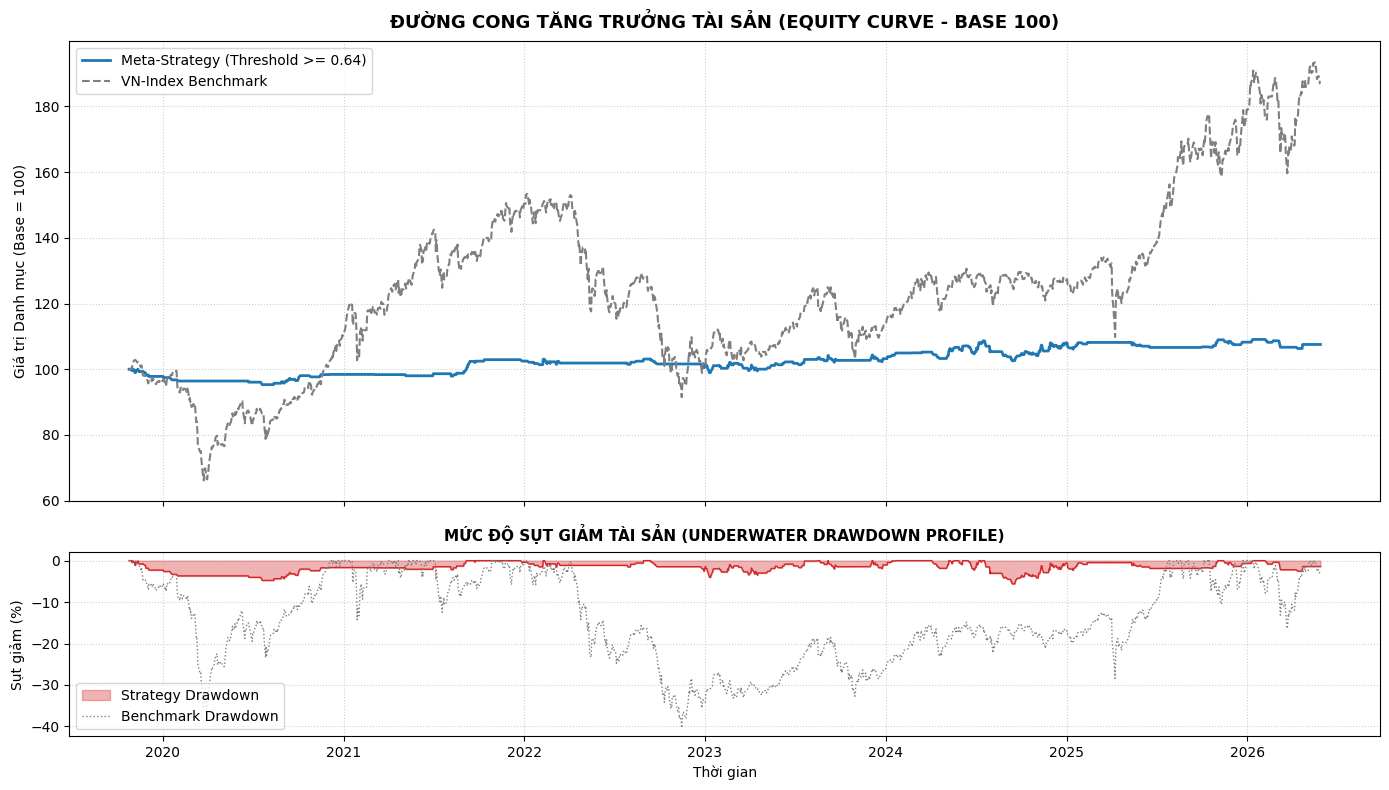

In [21]:
def run_consolidated_portfolio_backtest(df_events: pd.DataFrame,
                                        clean_price_dict: dict[str, pd.DataFrame],
                                        threshold: float = 0.64,
                                        max_positions: int = 5,
                                        cash_start: float = 100_000_000,
                                        round_trip_fee: float = 0.0030):
    """
    Portfolio Execution Engine & Tear Sheet Generator:
    - Mô phỏng thực thi danh mục đa tài sản có kiểm soát sức mua và số lượng vị thế.
    - So sánh trực tiếp NAV với Benchmark VN-Index.
    - Vẽ biểu đồ Equity Curve và Drawdown Profile.
    """
    # 1. Lọc các sự kiện vượt ngưỡng Meta-Filter
    df_valid = df_events[df_events['meta_prob_l1'] >= threshold].copy()
    df_valid = df_valid.sort_values(by=['time', 'meta_prob_l1'], ascending=[True, False])

    # 2. Tạo trục thời gian chuẩn từ VN-Index
    ref_ticker = list(clean_price_dict.keys())[0]
    mkt_series = clean_price_dict[ref_ticker]['mkt_close'].sort_index()
    calendar_dates = mkt_series.index[mkt_series.index >= df_valid['time'].min()]

    cash = cash_start
    holdings = []
    nav_history = []

    for current_date in calendar_dates:
        # A. Đóng các vị thế đã chạm rào cản tính đến phiên hiện tại
        still_open = []
        for pos in holdings:
            if current_date >= pos['exit_date']:
                # Giải phóng vốn + lợi nhuận ròng
                cash += pos['allocated_capital'] * (1.0 + pos['net_ret'])
            else:
                still_open.append(pos)
        holdings = still_open

        # B. Duyệt tín hiệu mới xuất hiện trong ngày
        available_slots = max_positions - len(holdings)
        day_signals = df_valid[df_valid['time'] == current_date]

        if available_slots > 0 and len(day_signals) > 0:
            selected_trades = day_signals.head(available_slots)
            total_current_nav = cash + sum([p['allocated_capital'] for p in holdings])
            target_pos_size = total_current_nav / max_positions

            for _, trade in selected_trades.iterrows():
                invest_amt = min(target_pos_size, cash)
                if invest_amt > 1_000_000: # Ngưỡng vốn tối thiểu cho một vị thế
                    cash -= invest_amt
                    # Quy đổi số ngày giao dịch nắm giữ sang ngày lịch
                    exit_date = trade['time'] + pd.Timedelta(days=int(trade['holding_days'] * 1.45))
                    net_ret = trade['barrier_return'] - round_trip_fee
                    holdings.append({
                        'ticker': trade['ticker'],
                        'allocated_capital': invest_amt,
                        'exit_date': exit_date,
                        'net_ret': net_ret
                    })

        # C. Ghi nhận NAV danh mục tại cuối phiên
        current_invested = sum([p['allocated_capital'] for p in holdings])
        total_nav = cash + current_invested
        nav_history.append({'time': current_date, 'nav': total_nav})

    # 3. Tổng hợp chuỗi dữ liệu hiệu suất
    df_nav = pd.DataFrame(nav_history).set_index('time')
    df_nav['benchmark'] = mkt_series.reindex(df_nav.index).ffill()

    # Chuẩn hóa về cơ số 100 để so sánh
    df_nav['Strategy_Norm'] = (df_nav['nav'] / cash_start) * 100.0
    df_nav['Benchmark_Norm'] = (df_nav['benchmark'] / df_nav['benchmark'].iloc[0]) * 100.0

    # Tính Drawdown
    roll_max = df_nav['Strategy_Norm'].cummax()
    df_nav['Drawdown'] = (df_nav['Strategy_Norm'] - roll_max) / roll_max * 100.0

    b_roll_max = df_nav['Benchmark_Norm'].cummax()
    df_nav['Benchmark_Drawdown'] = (df_nav['Benchmark_Norm'] - b_roll_max) / b_roll_max * 100.0

    # 4. Tính toán các chỉ số định lượng trọng yếu
    total_days = (df_nav.index[-1] - df_nav.index[0]).days
    cagr_strat = ((df_nav['Strategy_Norm'].iloc[-1] / 100.0) ** (365.25 / total_days) - 1.0) * 100.0
    cagr_bench = ((df_nav['Benchmark_Norm'].iloc[-1] / 100.0) ** (365.25 / total_days) - 1.0) * 100.0

    strat_daily_ret = df_nav['nav'].pct_change().dropna()
    bench_daily_ret = df_nav['benchmark'].pct_change().dropna()

    sharpe_strat = (strat_daily_ret.mean() / (strat_daily_ret.std() + 1e-8)) * np.sqrt(252)
    sharpe_bench = (bench_daily_ret.mean() / (bench_daily_ret.std() + 1e-8)) * np.sqrt(252)

    max_dd_strat = df_nav['Drawdown'].min()
    max_dd_bench = df_nav['Benchmark_Drawdown'].min()

    # 5. Báo cáo thống kê
    print("=" * 80)
    print("BÁO CÁO HIỆU NĂNG DANH MỤC THỰC CHIẾN (PORTFOLIO TEAR SHEET)")
    print("=" * 80)
    print(f"{'Chỉ số Đánh giá':<30} | {'Chiến lược Meta (0.64)':<22} | {'VN-INDEX Benchmark':<20}")
    print("-" * 80)
    print(f"{'Tổng Lợi nhuận (Cumulative Ret)':<30} | {df_nav['Strategy_Norm'].iloc[-1] - 100:>20.2f}% | {df_nav['Benchmark_Norm'].iloc[-1] - 100:>18.2f}%")
    print(f"{'Tỷ suất sinh lời năm (CAGR)':<30} | {cagr_strat:>20.2f}% | {cagr_bench:>18.2f}%")
    print(f"{'Chỉ số Sharpe (Risk-Free = 0)':<30} | {sharpe_strat:>20.2f}  | {sharpe_bench:>18.2f}")
    print(f"{'Độ sụt giảm tối đa (Max Drawdown)':<30} | {max_dd_strat:>20.2f}% | {max_dd_bench:>18.2f}%")
    print(f"{'Calmar Ratio (CAGR / |MaxDD|)':<30} | {cagr_strat / abs(max_dd_strat):>20.2f}  | {cagr_bench / abs(max_dd_bench):>18.2f}")
    print("=" * 80)

    # 6. Vẽ đồ thị Backtest chuyên nghiệp (2 Subplots)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, gridspec_kw={'height_ratios': [2.5, 1]})

    # Subplot 1: Equity Curve
    ax1.plot(df_nav.index, df_nav['Strategy_Norm'], label=f'Meta-Strategy (Threshold >= {threshold})', color='#1f77b4', lw=2)
    ax1.plot(df_nav.index, df_nav['Benchmark_Norm'], label='VN-Index Benchmark', color='#7f7f7f', lw=1.5, ls='--')
    ax1.set_title('ĐƯỜNG CONG TĂNG TRƯỞNG TÀI SẢN (EQUITY CURVE - BASE 100)', fontsize=13, fontweight='bold', pad=10)
    ax1.set_ylabel('Giá trị Danh mục (Base = 100)', fontsize=10)
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend(loc='upper left', frameon=True)

    # Subplot 2: Underwater Profile (Drawdown)
    ax2.fill_between(df_nav.index, df_nav['Drawdown'], 0, color='#d62728', alpha=0.35, label='Strategy Drawdown')
    ax2.plot(df_nav.index, df_nav['Drawdown'], color='#d62728', lw=1)
    ax2.plot(df_nav.index, df_nav['Benchmark_Drawdown'], color='#7f7f7f', lw=1, ls=':', label='Benchmark Drawdown')
    ax2.set_title('MỨC ĐỘ SỤT GIẢM TÀI SẢN (UNDERWATER DRAWDOWN PROFILE)', fontsize=11, fontweight='bold', pad=8)
    ax2.set_ylabel('Sụt giảm (%)', fontsize=10)
    ax2.set_xlabel('Thời gian', fontsize=10)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='lower left', frameon=True)

    plt.tight_layout()
    plt.show()

    return df_nav

# Thực thi hàm backtest và xuất biểu đồ
df_portfolio_nav = run_consolidated_portfolio_backtest(
    df_events=df_meta_l1,
    clean_price_dict=clean_price_dict,
    threshold=0.64,
    max_positions=5,
    cash_start=100_000_000
)

# Feature Diagnosis & The Visualization

BẢNG TRỌNG SỐ ĐẶC TRƯNG NGOẠI SINH CỦA META-MODEL (L1 COEFFICIENTS)
            Feature  Mean_Weight  Std_Weight  Active_Folds                 Impact
        feat_gk_vol      -0.2141      0.0378             5 Tiêu cực (Cảnh báo SL)
   feat_market_corr       0.1558      0.0927             4   Tích cực (Ủng hộ TP)
   feat_flow_zscore       0.0889      0.0238             5   Tích cực (Ủng hộ TP)
  feat_relative_vol      -0.0111      0.0382             3 Tiêu cực (Cảnh báo SL)
feat_market_breadth       0.0096      0.0105             3   Tích cực (Ủng hộ TP)


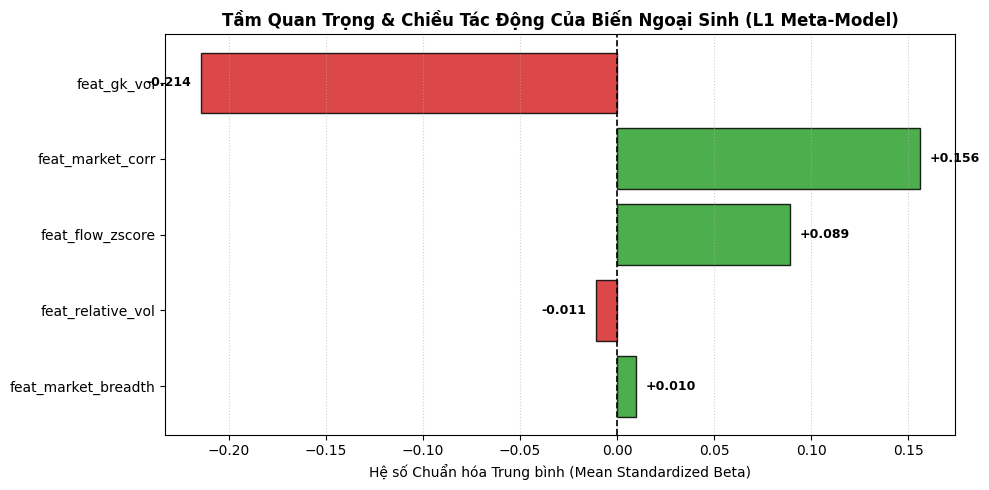

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def analyze_meta_feature_importance(trained_models, feature_names):
    """
    Trích xuất và trực quan hóa trọng số L1 (Standardized Coefficients)
    của Meta-Model qua 5 Folds kiểm định chéo.
    """
    if not trained_models:
        raise ValueError("Danh sách trained_models rỗng.")

    records = []
    for fold_idx, model in enumerate(trained_models):
        coefs = model.coef_[0]
        for f_name, coef_val in zip(feature_names, coefs):
            records.append({
                'Fold': f'Fold_{fold_idx + 1}',
                'Feature': f_name,
                'Weight': coef_val,
                'Abs_Weight': abs(coef_val)
            })

    df_records = pd.DataFrame(records)

    # Tổng hợp thống kê qua 5 Folds
    summary = df_records.groupby('Feature').agg(
        Mean_Weight=('Weight', 'mean'),
        Std_Weight=('Weight', 'std'),
        Mean_Abs_Weight=('Abs_Weight', 'mean'),
        Active_Folds=('Weight', lambda x: (x != 0).sum())
    ).reset_index()

    summary['Std_Weight'] = summary['Std_Weight'].fillna(0.0)
    summary['Impact'] = summary['Mean_Weight'].apply(
        lambda w: 'Tích cực (Ủng hộ TP)' if w > 0 else ('Tiêu cực (Cảnh báo SL)' if w < 0 else 'Bị triệt tiêu (0)')
    )
    summary = summary.sort_values(by='Mean_Abs_Weight', ascending=False).reset_index(drop=True)

    print("=" * 80)
    print("BẢNG TRỌNG SỐ ĐẶC TRƯNG NGOẠI SINH CỦA META-MODEL (L1 COEFFICIENTS)")
    print("=" * 80)
    print(summary[['Feature', 'Mean_Weight', 'Std_Weight', 'Active_Folds', 'Impact']].round(4).to_string(index=False))

    # Biểu đồ thanh phân kỳ thể hiện chiều tác động
    plt.figure(figsize=(10, 5))
    colors = ['#2ca02c' if w > 0 else '#d62728' for w in summary['Mean_Weight']]
    bars = plt.barh(summary['Feature'], summary['Mean_Weight'], color=colors, edgecolor='black', alpha=0.85)
    plt.axvline(0, color='black', lw=1.2, ls='--')

    for bar in bars:
        w = bar.get_width()
        plt.text(w + (0.005 if w >= 0 else -0.005), bar.get_y() + bar.get_height() / 2,
                 f'{w:+.3f}', va='center', ha='left' if w >= 0 else 'right', fontsize=9, fontweight='bold')

    plt.title('Tầm Quan Trọng & Chiều Tác Động Của Biến Ngoại Sinh (L1 Meta-Model)', fontsize=12, fontweight='bold')
    plt.xlabel('Hệ số Chuẩn hóa Trung bình (Mean Standardized Beta)', fontsize=10)
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

    return summary

# Thực thi trực tiếp
meta_feature_names = [
    'feat_relative_vol',
    'feat_market_corr',
    'feat_flow_zscore',
    'feat_market_breadth',
    'feat_gk_vol'
]

df_feature_summary = analyze_meta_feature_importance(
    trained_models=models_l1,
    feature_names=meta_feature_names
)